# Análisis exploratorio de SFC 414 (desembolsos de crédito por municipio)

Tabla `prueba-ofr.Inclusion_Financiera.SFC414_DASH` del Observatorio. Viene del **formato 414 de la Superintendencia Financiera** y reporta los desembolsos de crédito de las entidades vigiladas. A diferencia de FINAGRO, cada fila **no es un crédito sino un agregado**: el monto y el número de créditos desembolsados en una fecha de corte, en un municipio, para una combinación de tipo de persona, sexo, tipo de crédito y tipo de garantía.

**Sin cobro:** la tabla completa se bajó una sola vez con `descargar_tablas_profesor.py sfc414`, que usa la API gratuita `tabledata.list` (la del botón *Preview*), a `datos/profesor/sfc414/*.parquet`. Este notebook no ejecuta SQL en BigQuery.

El análisis tiene dos partes:
1. **Descripción de las variables**: tipo de cada una, distribución de las numéricas y categorías de las categóricas.
2. **Relación de los montos y del número de créditos desembolsados con el resto de variables**: tiempo, tipo de crédito, garantía, tipo de persona, sexo, ubicación (región, departamento, municipio, ruralidad, PDET) y tasa de interés.

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from IPython.display import display

# --- Carga: las columnas de texto se leen como categoricas (dictionary) para ahorrar memoria
partes = sorted(Path("datos/profesor/sfc414").glob("parte-*.parquet"))
esquema = pq.read_schema(partes[0])
texto = [c.name for c in esquema if str(c.type) == "string"]
tabla = pa.concat_tables([pq.read_table(p, read_dictionary=texto) for p in partes]).unify_dictionaries()
sfc = tabla.to_pandas()
del tabla
sfc["Fecha_Corte"] = pd.to_datetime(sfc["Fecha_Corte"])
sfc["anio"] = sfc["Fecha_Corte"].dt.year

# Nombres cortos para las dos medidas principales
MONTO, NCRED, TASA = "Montos_desembolsados", "Numero_de_creditos_desembolsados", "Tasa_efectiva_promedio_ponderada_AD"
BILLON = 1e12  # 1 billon = un millon de millones de COP

# --- Estilo de graficos (paleta categorica en orden fijo; secuencial azul para mapas de calor)
PALETA = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
GRIS_OTROS = "#b5b3ac"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.edgecolor": "#c3c2b7",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelcolor": "#52514e", "xtick.color": "#52514e", "ytick.color": "#52514e",
    "text.color": "#0b0b0b", "legend.frameon": False, "figure.dpi": 110,
})
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
pd.set_option("display.max_rows", 80)
pd.set_option("display.max_columns", None)

print(f"{len(sfc):,} filas, {len(esquema)} columnas, {sfc.memory_usage(deep=True).sum() / 1e6:,.0f} MB en memoria")
print("Fechas de corte:", sfc["Fecha_Corte"].min().date(), "a", sfc["Fecha_Corte"].max().date(),
      f"({sfc['Fecha_Corte'].nunique()} cortes)")
sfc.head()

1,977,282 filas, 17 columnas, 117 MB en memoria
Fechas de corte: 2023-09-29 a 2026-09-18 (156 cortes)


,Fecha_Corte,Tipo_de_persona,Sexo,Tipo_de_credito,Tipo_de_garantia,Montos_desembolsados,Numero_de_creditos_desembolsados,Codigo_Municipio,nombre_departamento,nombre_municipio,region,fecha,ruralidad,Rural_Urbano,Tasa_efectiva_promedio_ponderada_AD,MPIO,PDET_Nom,anio
0,2026-05-22,Natural,No binario,Consumo,Garantia idónea o no idónea,"142,900,677.43",728,05001,Antioquia,Medellín,Eje cafetero,"2,026.00",Ciudades y aglomeraciones,Urbano,20.50,05001,NO PDET,2026
1,2026-05-15,Natural,No binario,Consumo,Garantia idónea o no idónea,"150,845,135.83",659,05001,Antioquia,Medellín,Eje cafetero,"2,026.00",Ciudades y aglomeraciones,Urbano,19.88,05001,NO PDET,2026
2,2025-05-16,Natural,No binario,Consumo,Sin garantia,"298,169.00",2,05001,Antioquia,Medellín,Eje cafetero,"2,025.00",Ciudades y aglomeraciones,Urbano,21.76,05001,NO PDET,2025
3,2025-06-20,Natural,No binario,Consumo,Garantia idónea o no idónea,"21,334,800.00",11,05001,Antioquia,Medellín,Eje cafetero,"2,025.00",Ciudades y aglomeraciones,Urbano,47.65,05001,NO PDET,2025
4,2026-09-04,Natural,No binario,Consumo,Garantia idónea o no idónea,"172,739,973.04",881,05001,Antioquia,Medellín,Eje cafetero,"2,026.00",Ciudades y aglomeraciones,Urbano,19.28,05001,NO PDET,2026


## 1. Descripción de las variables

### 1.1 Tipo de cada variable

Para cada columna se muestra el tipo con el que viene de BigQuery y el tipo *analítico*, es decir, cómo conviene tratarla. También se muestran el porcentaje de valores vacíos, el número de valores distintos y el valor más frecuente. Además se comprueba qué identifica una fila: si la combinación de fecha de corte, municipio, tipo de persona, sexo, tipo de crédito y tipo de garantía es única, cada fila es un **agregado** de varios créditos.

In [2]:
TIPO_ANALITICO = {
    "Fecha_Corte": "Fecha (corte semanal)",
    "Tipo_de_persona": "Categórica",
    "Sexo": "Categórica",
    "Tipo_de_credito": "Categórica",
    "Tipo_de_garantia": "Categórica",
    MONTO: "Numérica continua (COP)",
    NCRED: "Numérica discreta (conteo)",
    "Codigo_Municipio": "Categórica (código DANE)",
    "nombre_departamento": "Categórica (departamento)",
    "nombre_municipio": "Categórica (municipio)",
    "region": "Categórica",
    "fecha": "Numérica discreta (año)",
    "ruralidad": "Categórica ordinal",
    "Rural_Urbano": "Categórica binaria",
    TASA: "Numérica continua (tasa %, ponderada)",
    "MPIO": "Categórica (código DANE)",
    "PDET_Nom": "Categórica binaria",
}
columnas = [c.name for c in esquema]


def vacios(s):
    """Nulos + texto vacio."""
    nulos = s.isna()
    if s.dtype == "category" or s.dtype == object:
        nulos |= s.astype("object").eq("")
    return nulos


resumen = pd.DataFrame({
    "tipo_bigquery": [str(esquema.field(c).type) for c in columnas],
    "tipo_analitico": [TIPO_ANALITICO[c] for c in columnas],
    "% vacíos": [vacios(sfc[c]).mean() * 100 for c in columnas],
    "valores distintos": [sfc[c].nunique() for c in columnas],
    "valor más frecuente": [sfc[c].mode(dropna=True).iloc[0] for c in columnas],
}, index=columnas)

LLAVE = ["Fecha_Corte", "Codigo_Municipio", "Tipo_de_persona", "Sexo", "Tipo_de_credito", "Tipo_de_garantia"]
print("¿La llave (fecha, municipio, persona, sexo, tipo de crédito, garantía) es única?",
      not sfc.duplicated(LLAVE).any())
print("Días de la semana de Fecha_Corte:", sorted(sfc["Fecha_Corte"].dt.day_name().unique()))
print("¿MPIO es igual a Codigo_Municipio?", (sfc["MPIO"].astype(str) == sfc["Codigo_Municipio"].astype(str)).all())
print(f"¿'fecha' es el año de Fecha_Corte? en {(sfc['fecha'] == sfc['anio']).mean():.2%} de las filas")
resumen.style.format({"% vacíos": "{:.3f}", "valores distintos": "{:,.0f}"})

¿La llave (fecha, municipio, persona, sexo, tipo de crédito, garantía) es única? True


Días de la semana de Fecha_Corte: ['Friday']


¿MPIO es igual a Codigo_Municipio? True
¿'fecha' es el año de Fecha_Corte? en 99.99% de las filas


,tipo_bigquery,tipo_analitico,% vacíos,valores distintos,valor más frecuente
Fecha_Corte,date32[day],Fecha (corte semanal),0.000,156,2026-05-29 00:00:00
Tipo_de_persona,string,Categórica,0.000,3,Natural
Sexo,string,Categórica,0.000,5,Masculino
Tipo_de_credito,string,Categórica,0.000,8,Crédito productivo
Tipo_de_garantia,string,Categórica,0.000,7,Sin garantia
Montos_desembolsados,double,Numérica continua (COP),0.000,"1,170,969",10000000.000000
Numero_de_creditos_desembolsados,int64,Numérica discreta (conteo),0.000,"23,354",1
Codigo_Municipio,string,Categórica (código DANE),0.000,"1,123",11001
nombre_departamento,string,Categórica (departamento),0.011,33,Antioquia
nombre_municipio,string,Categórica (municipio),0.011,"1,039",La Unión


### 1.2 Variables numéricas

Las tres medidas de la tabla son el monto desembolsado, el número de créditos desembolsados y la tasa efectiva promedio ponderada. Se agrega una cuarta que se calcula a partir de ellas: el **monto promedio por crédito** de cada fila, que es el monto dividido por el número de créditos. Como cada fila agrupa muchos créditos, estas distribuciones describen *filas*, es decir, combinaciones de semana, municipio y segmento, y no créditos individuales.

In [3]:
sfc["monto_por_credito"] = sfc[MONTO] / sfc[NCRED]
NUMERICAS = [MONTO, NCRED, "monto_por_credito", TASA]
percentiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
desc_num = sfc[NUMERICAS].describe(percentiles=percentiles).T
desc_num.insert(1, "% ceros", [(sfc[c] == 0).mean() * 100 for c in NUMERICAS])
desc_num["count"] = desc_num["count"].astype(int)

# Que tan concentrados estan el monto y el numero de creditos en pocas filas
for col, nombre in [(MONTO, "del monto"), (NCRED, "de los créditos")]:
    orden = sfc[col].sort_values(ascending=False)
    top1 = orden.iloc[: len(orden) // 100].sum() / orden.sum()
    print(f"El 1% de filas más grandes suma {top1:.1%} {nombre}")
desc_num

El 1% de filas más grandes suma 83.0% del monto
El 1% de filas más grandes suma 88.8% de los créditos


,count,% ceros,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Montos_desembolsados,1977282,0.00,"1,054,721,483.00","23,823,720,736.23",0.01,"35,488.66","447,466.15","5,970,000.00","22,100,000.00","78,498,650.50","940,236,883.79","9,604,300,213.79","3,215,490,031,553.71"
Numero_de_creditos_desembolsados,1977282,0.00,954.50,"31,748.96",1.00,1.00,1.00,1.00,4.00,21.00,564.00,"7,886.00","3,112,910.00"
monto_por_credito,1977282,0.00,"28,035,333.57","597,208,042.00",0.01,"26,000.00","125,000.00","514,845.25","3,900,000.00","12,000,000.00","79,566,666.67","278,336,500.00","350,000,000,000.00"
Tasa_efectiva_promedio_ponderada_AD,1977155,2.86,28.18,17.35,0.00,0.00,6.44,16.35,23.23,36.80,64.80,72.90,89.73


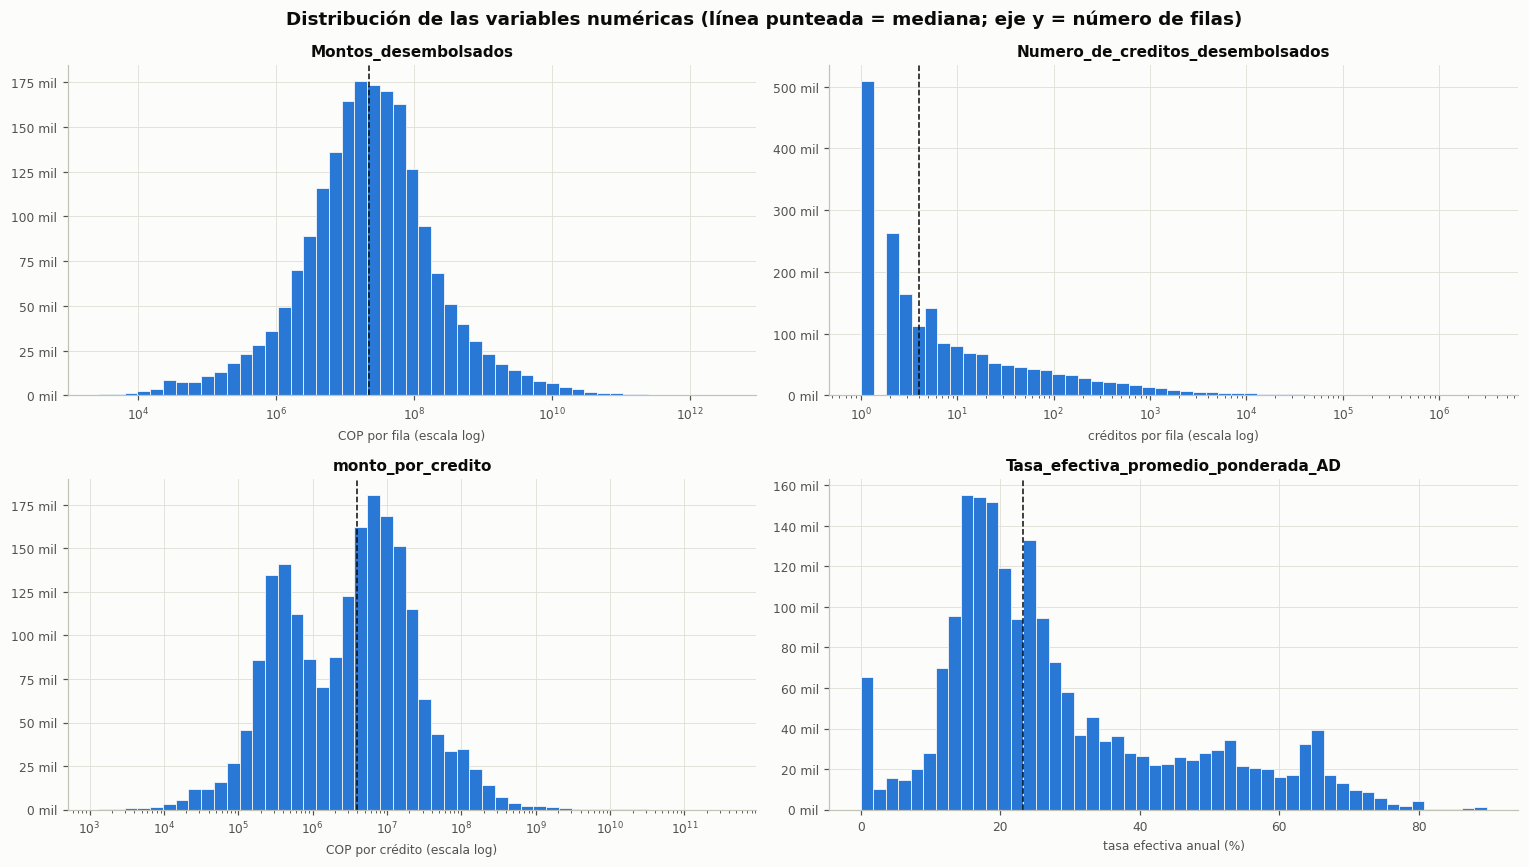

In [4]:
def histograma(ax, s, titulo, log=False, unidad=""):
    s = s.dropna()
    if log:
        s = s[s > 0]  # en escala log solo se grafican los valores positivos
        s = s[s >= s.quantile(0.001)]  # se omite el 0.1% mas bajo (centavos), que estira el eje
        bins = np.logspace(np.log10(s.min()), np.log10(s.max()), 50)
        ax.set_xscale("log")
    else:
        bins = 50
    mediana = s.median()
    ax.hist(s, bins=bins, color=PALETA[0], edgecolor="#fcfcfb", linewidth=0.5)
    ax.axvline(mediana, color="#0b0b0b", linewidth=1, linestyle="--")
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel(unidad, fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e3:,.0f} mil"))
    ax.tick_params(labelsize=8)


fig, ejes = plt.subplots(2, 2, figsize=(14, 8))
histograma(ejes[0, 0], sfc[MONTO], MONTO, log=True, unidad="COP por fila (escala log)")
histograma(ejes[0, 1], sfc[NCRED], NCRED, log=True, unidad="créditos por fila (escala log)")
histograma(ejes[1, 0], sfc["monto_por_credito"], "monto_por_credito", log=True, unidad="COP por crédito (escala log)")
histograma(ejes[1, 1], sfc[TASA], TASA, unidad="tasa efectiva anual (%)")
fig.suptitle("Distribución de las variables numéricas (línea punteada = mediana; eje y = número de filas)",
             fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

### 1.3 Variables categóricas

Para cada variable categórica se listan sus categorías con tres medidas: el número de **filas**, la suma de **créditos** desembolsados y la suma del **monto**. Las variables con muchas categorías (municipios, departamentos) muestran solo las 15 con más monto y agrupan el resto en "Otras". Los vacíos aparecen como "Sin dato".

In [5]:
def etiquetas(s):
    """Serie con nulos y texto vacio reemplazados por 'Sin dato'."""
    s = s.astype("object")
    return s.where(s.notna() & s.ne(""), "Sin dato")


def medidas(s):
    """Filas, creditos y monto por categoria de s, con sus participaciones."""
    g = sfc.groupby(etiquetas(s))
    t = pd.DataFrame({"filas": g.size(), "créditos": g[NCRED].sum(), "monto (billones COP)": g[MONTO].sum() / BILLON})
    t["% filas"] = t["filas"] / t["filas"].sum() * 100
    t["% créditos"] = t["créditos"] / t["créditos"].sum() * 100
    t["% monto"] = t["monto (billones COP)"] / t["monto (billones COP)"].sum() * 100
    return t.sort_values("monto (billones COP)", ascending=False)


def categorias(col, top=15):
    t = medidas(sfc[col])
    if len(t) > top:
        resto = t.iloc[top:].sum()
        t = pd.concat([t.iloc[:top], resto.to_frame(f"Otras ({len(t) - top} categorías)").T])
    t.index.name = col
    return t[["filas", "% filas", "créditos", "% créditos", "monto (billones COP)", "% monto"]]


FORMATO = {"filas": "{:,.0f}", "% filas": "{:.2f}", "créditos": "{:,.0f}", "% créditos": "{:.2f}",
           "monto (billones COP)": "{:,.1f}", "% monto": "{:.2f}"}
CATEGORICAS = ["Tipo_de_persona", "Sexo", "Tipo_de_credito", "Tipo_de_garantia", "region", "ruralidad",
               "Rural_Urbano", "PDET_Nom", "nombre_departamento"]  # los municipios se analizan en la seccion 2.5
for col in CATEGORICAS:
    print(f"\n{col} — {sfc[col].nunique():,} categorías distintas")
    display(categorias(col).style.format(FORMATO))


Tipo_de_persona — 3 categorías distintas


,filas,% filas,créditos,% créditos,monto (billones COP),% monto
Tipo_de_persona,,,,,,
Jurídica,"195,445",9.88,"71,534,915",3.79,"1,269.7",60.88
Natural,"1,781,835",90.12,"1,815,784,884",96.21,815.8,39.12
N/A,2,0.00,2,0.00,0.0,0.00



Sexo — 5 categorías distintas


,filas,% filas,créditos,% créditos,monto (billones COP),% monto
Sexo,,,,,,
No aplica,"195,447",9.88,"71,534,917",3.79,"1,269.7",60.88
Masculino,"919,994",46.53,"964,855,948",51.12,454.3,21.79
Femenino,"856,871",43.34,"850,565,458",45.07,361.4,17.33
No binario,"4,687",0.24,"361,829",0.02,0.1,0.00
Trans,283,0.01,"1,649",0.00,0.0,0.00



Tipo_de_credito — 8 categorías distintas


...

,filas,% filas,créditos,% créditos,monto (billones COP),% monto
Rural_Urbano,,,,,,
Urbano,"1,113,408",56.31,"1,862,920,750",98.71,"2,050.4",98.32
Rural + Disperso,"863,874",43.69,"24,399,051",1.29,35.1,1.68



PDET_Nom — 2 categorías distintas


,filas,% filas,créditos,% créditos,monto (billones COP),% monto
PDET_Nom,,,,,,
NO PDET,"1,675,860",84.76,"1,841,156,348",97.55,"2,028.8",97.28
PDET,"301,422",15.24,"46,163,453",2.45,56.6,2.72



nombre_departamento — 33 categorías distintas


,filas,% filas,créditos,% créditos,monto (billones COP),% monto
nombre_departamento,,,,,,
"Bogotá, D.C.","6,809",0.34,"900,604,788",47.72,952.9,45.69
Antioquia,"240,518",12.16,"293,887,936",15.57,388.5,18.63
Valle del Cauca,"104,132",5.27,"148,797,152",7.88,198.7,9.53
Atlántico,"45,326",2.29,"85,089,796",4.51,88.8,4.26
Santander,"131,602",6.66,"65,119,236",3.45,63.0,3.02
Cundinamarca,"223,140",11.29,"77,328,318",4.10,61.0,2.93
Bolívar,"67,653",3.42,"39,383,567",2.09,36.9,1.77
Risaralda,"30,984",1.57,"32,671,641",1.73,31.9,1.53
Tolima,"93,897",4.75,"26,073,508",1.38,28.7,1.38


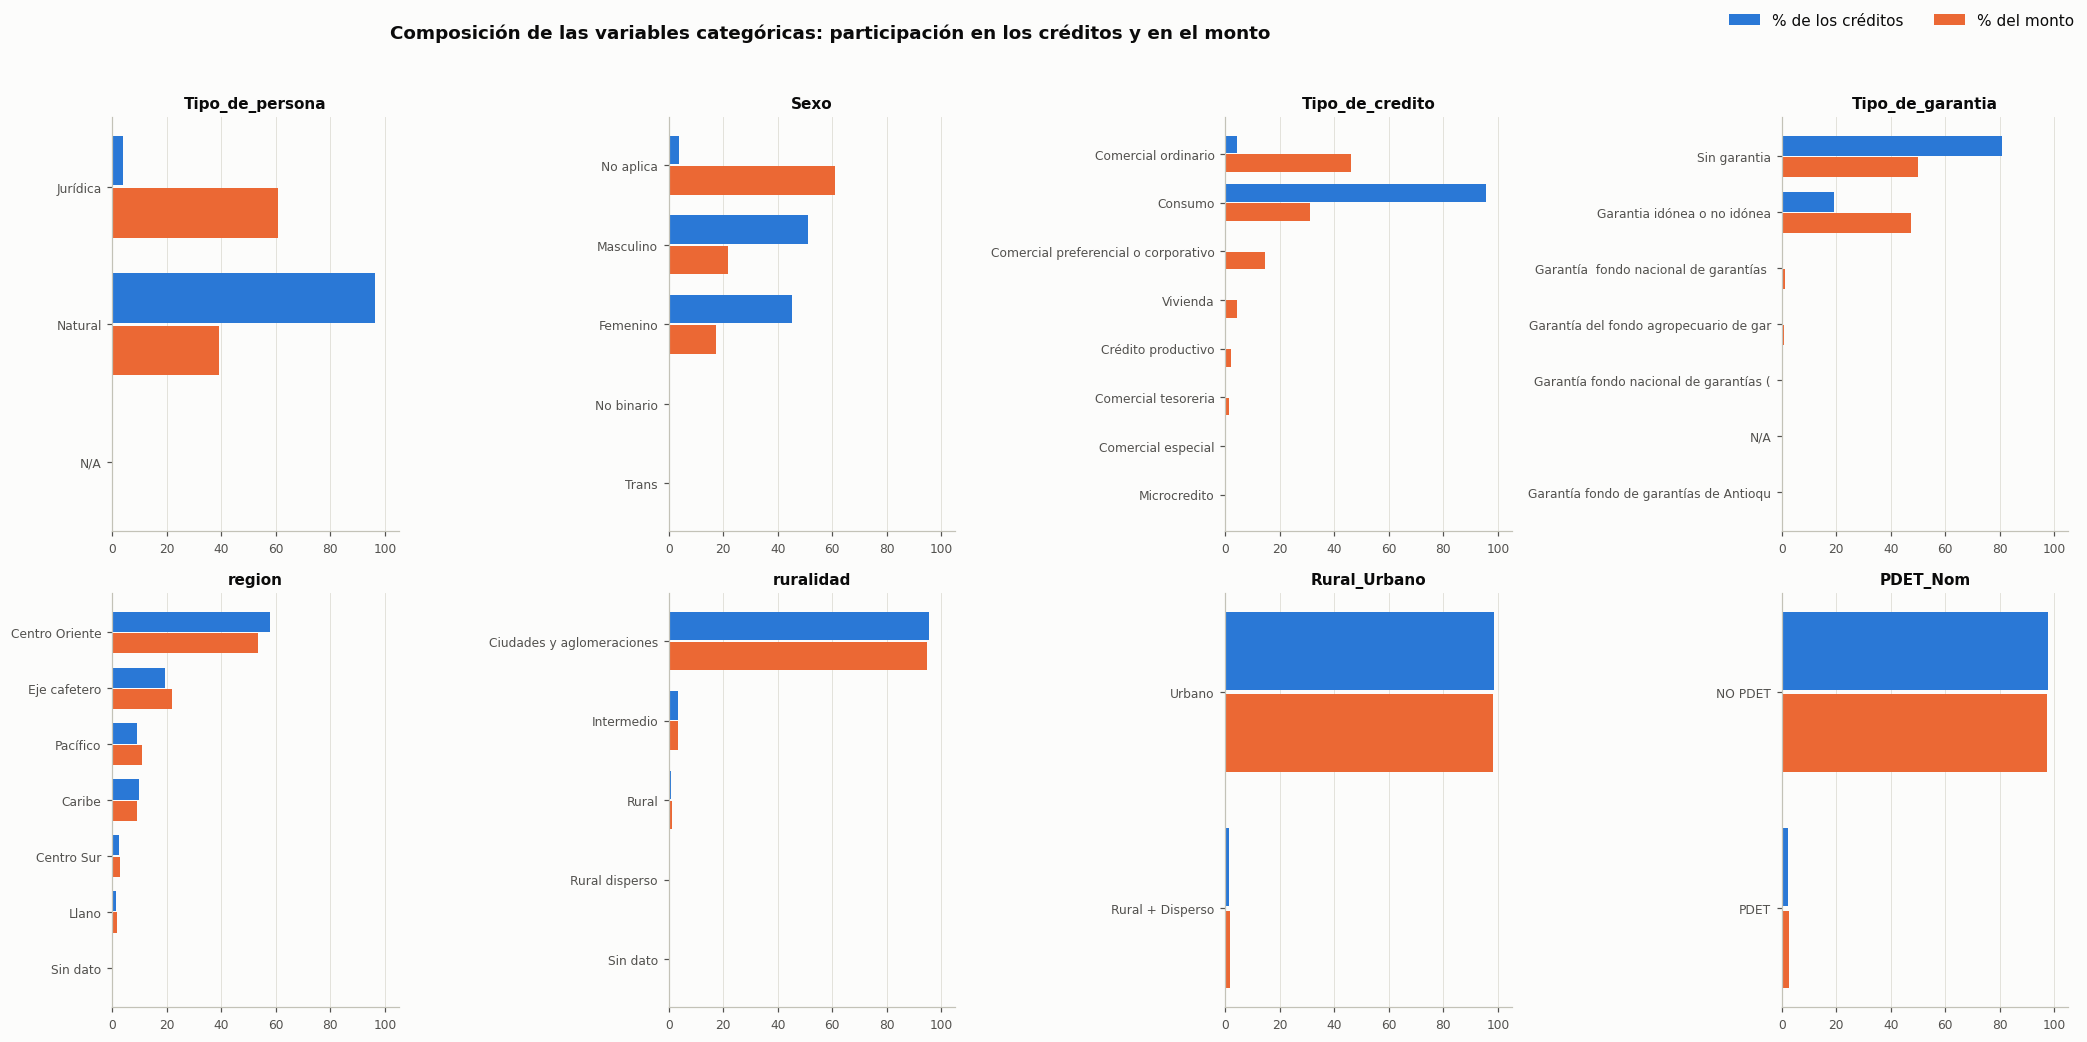

In [6]:
# Composicion de las categoricas con pocas categorias: % de los creditos frente a % del monto
POCAS = ["Tipo_de_persona", "Sexo", "Tipo_de_credito", "Tipo_de_garantia", "region", "ruralidad",
         "Rural_Urbano", "PDET_Nom"]
fig, ejes = plt.subplots(2, 4, figsize=(19, 9.5))
for ax, col in zip(ejes.flat, POCAS):
    t = medidas(sfc[col]).iloc[::-1]
    y = np.arange(len(t))
    ax.barh(y + 0.19, t["% créditos"], height=0.36, color=PALETA[0], label="% de los créditos")
    ax.barh(y - 0.19, t["% monto"], height=0.36, color=PALETA[1], label="% del monto")
    ax.set_yticks(y, [str(i)[:38] for i in t.index])
    ax.set_xlim(0, 105)
    ax.set_title(col, fontsize=10)
    ax.tick_params(labelsize=8)
    ax.grid(axis="y", visible=False)
h, l = ejes[0, 0].get_legend_handles_labels()
fig.legend(h, l, loc="upper right", ncol=2, fontsize=10)
fig.suptitle("Composición de las variables categóricas: participación en los créditos y en el monto",
             fontsize=12, fontweight="bold", x=0.4)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

### 1.4 Descripción de cada variable

Cada fila de la tabla es un **agregado**, no un crédito: suma los créditos desembolsados en una semana, en un municipio, para una combinación de tipo de persona, sexo, tipo de crédito y tipo de garantía (esa combinación es única). En total son 1.887 millones de créditos por 2.085 billones de pesos en tres años. El número es tan alto porque el consumo incluye muchos desembolsos pequeños, del orden de 360 mil pesos en promedio.

**Fecha**

| Variable | Tipo | Descripción |
|---|---|---|
| `Fecha_Corte` | Fecha | Fecha de corte semanal, siempre un viernes. Hay 156 cortes, del 29-sep-2023 al 18-sep-2026. **2023 (14 semanas) y 2026 (38 semanas) están incompletos.** |
| `fecha` | Numérica discreta (año) | El año de `Fecha_Corte`. Solo está vacío en las 217 filas sin ubicación. |

**Ubicación**

| Variable | Tipo | Descripción |
|---|---|---|
| `Codigo_Municipio` | Categórica (código DANE) | Municipio donde se reporta el desembolso, en 5 dígitos. Hay 1.123 municipios. |
| `MPIO` | Categórica (código DANE) | Idéntica a `Codigo_Municipio`. |
| `nombre_departamento`, `nombre_municipio` | Categóricas | Nombre del departamento (32 más Bogotá) y del municipio. Están vacíos en 217 filas (0,01 %), de dos códigos del Chocó (27493 y 27086) que no están en el catálogo de municipios. |
| `region` | Categórica | Seis regiones. En monto: Centro Oriente 53,6 % (incluye Bogotá), Eje cafetero 22,0 % (incluye Antioquia), Pacífico 10,9 %, Caribe 9,1 %, Centro Sur 2,8 % y Llano 1,7 %. |
| `ruralidad` | Categórica ordinal | Categoría de ruralidad del DNP del municipio. **Ciudades y aglomeraciones concentran el 95 % de los créditos y del monto**, aunque solo el 19 % de las filas. |
| `Rural_Urbano` | Categórica binaria | Agrupa la ruralidad: "Urbano" = ciudades + intermedio y "Rural + Disperso" = rural + rural disperso. Rural + Disperso tiene el 1,7 % del monto. |
| `PDET_Nom` | Categórica binaria | Si el municipio es PDET: 15 % de las filas, pero solo el 2,5 % de los créditos y el 2,7 % del monto. |

**Segmento del deudor y del crédito**

| Variable | Tipo | Descripción |
|---|---|---|
| `Tipo_de_persona` | Categórica | Natural: 96,2 % de los créditos y 39,1 % del monto. Jurídica: 3,8 % de los créditos y 60,9 % del monto. Hay 2 filas con "N/A". |
| `Sexo` | Categórica | Masculino, Femenino, No binario, Trans y "No aplica". "No aplica" corresponde a las personas jurídicas. Entre personas naturales, las mujeres tienen el 46,8 % de los créditos y el 44,3 % del monto. |
| `Tipo_de_credito` | Categórica | Modalidad de la Superintendencia Financiera. **Consumo** tiene el 95,5 % de los créditos pero el 31,2 % del monto. **Comercial ordinario** tiene el 4,2 % de los créditos y el 46,0 % del monto. Comercial preferencial o corporativo, el 14,7 % del monto. Vivienda, el 4,2 %. **Crédito productivo**, el 2,2 % del monto, aunque es el 44 % de las filas porque aparece en casi todos los municipios. Tesorería, el 1,3 %, y comercial especial, el 0,4 %. "Microcredito" tiene solo 3 filas: la modalidad fue reemplazada por el crédito productivo. |
| `Tipo_de_garantia` | Categórica | Siete etiquetas. Sin garantía: 80,8 % de los créditos y 49,9 % del monto. Idónea o no idónea: 19,0 % y 47,4 %. Los fondos de garantías (FNG, FGA y FAG) suman el 2,6 % del monto. **Hasta sep-2025 FNG y FGA se reportan en una sola etiqueta; desde oct-2025, por separado.** "N/A" solo aparece en oct–dic 2025. |

**Medidas**

| Variable | Tipo | Descripción |
|---|---|---|
| `Montos_desembolsados` | Numérica continua | Monto de la fila, en pesos nominales. Es muy asimétrica: la mediana es 22 millones, el promedio 1.055 millones y el máximo 3,2 billones (comercial ordinario de personas jurídicas en Bogotá). El 1 % de filas más grandes suma el 83 % del monto. |
| `Numero_de_creditos_desembolsados` | Numérica discreta | Número de créditos de la fila. La mediana es 4 y una de cada cuatro filas tiene un solo crédito. El máximo es 3,1 millones (consumo sin garantía de hombres en Bogotá, en una semana). El 1 % de filas más grandes suma el 89 % de los créditos. |
| `Tasa_efectiva_promedio_ponderada_AD` | Numérica continua | Tasa efectiva anual, en %, promedio ponderado de los créditos de la fila. La mediana es 23,2 % y el rango va de 0 % a 89,7 %. El 2,9 % de las filas tiene tasa 0 (casi todas de comercial ordinario y consumo, probablemente promociones o datos sin tasa) y 127 filas no tienen tasa. |
| `monto_por_credito` (calculada) | Numérica continua | Monto dividido por el número de créditos de la fila. La mediana es 3,9 millones. |

## 2. Relación de los montos y del número de créditos con el resto de variables

En esta parte se mira cómo se reparten el **monto desembolsado** y el **número de créditos desembolsados** según cada variable: en el tiempo, por tipo de crédito, por garantía, por tipo de persona y sexo, por ubicación y según la tasa de interés.

Algunas notas para leer los resultados:
- **Número frente a dinero:** hay que mirarlos por separado. El consumo pone casi todos los créditos pero no la mayor parte del dinero, así que las participaciones en el número y en el monto cuentan historias distintas.
- **Monto promedio por crédito:** en cada grupo se calcula como la suma del monto dividida por la suma del número de créditos.
- **Tasa ponderada:** la tasa de un grupo es el promedio de `Tasa_efectiva_promedio_ponderada_AD` ponderado por el monto, porque cada fila ya es un promedio ponderado de sus créditos.
- **Periodo:** 156 cortes semanales (todos los viernes), del 29-sep-2023 al 18-sep-2026. **2023 (14 semanas) y 2026 (38 semanas) están incompletos**, así que para comparar niveles entre años se usa el **promedio semanal**. Las participaciones (%) sí se pueden comparar directamente.
- **Montos nominales** en pesos colombianos: 1 billón = un millón de millones de COP.

In [7]:
# --- Garantia: nombres cortos. Hasta sep-2025 FNG y FGA se reportan juntos ("FNG o FGA"); desde oct-2025 por
# separado. Para comparar en el tiempo se unen en "FNG o FGA".
GARANTIA_CORTA = {
    "Sin garantia": "Sin garantía",
    "Garantia idónea o no idónea": "Idónea o no idónea",
    "Garantía del fondo agropecuario de garantías (FAG)": "FAG (agropecuario)",
    "Garantía  fondo nacional de garantías (FNG) o Fondo de Garantías de Antioquia (FGA)": "FNG o FGA",
    "Garantía fondo nacional de garantías (FNG)": "FNG o FGA",
    "Garantía fondo de garantías de Antioquia (FGA)": "FNG o FGA",
    "N/A": "N/A",
}
sfc["garantia"] = sfc["Tipo_de_garantia"].astype("object").map(GARANTIA_CORTA).astype("category")
print(pd.crosstab(sfc["Tipo_de_garantia"].astype("object").map(lambda s: s[:60]),
                  sfc["Fecha_Corte"].dt.to_period("Q")).to_string())

# --- Ubicacion: dos codigos del Choco (prefijo 27) no traen departamento ni region; se completan a mano
sin_ubicacion = sfc["region"].isna()
print("\nFilas sin ubicación por código:", sfc.loc[sin_ubicacion, "Codigo_Municipio"].astype("object").value_counts().to_dict())
sfc["departamento"] = sfc["nombre_departamento"].astype("object").where(~sin_ubicacion, "Chocó").astype("category")
sfc["region_c"] = sfc["region"].astype("object").where(~sin_ubicacion, "Pacífico").astype("category")

# --- Semanas con datos en cada año (2023 y 2026 incompletos)
semanas = sfc.groupby("anio")["Fecha_Corte"].agg(desde="min", hasta="max", semanas="nunique")
semanas

Fecha_Corte                                                   2023Q3  2023Q4  2024Q1  2024Q2  2024Q3  2024Q4  2025Q1  2025Q2  2025Q3  2025Q4  2026Q1  2026Q2  2026Q3
Tipo_de_garantia                                                                                                                                                    
Garantia idónea o no idónea                                     4293   53038   51838   51685   51167   53171   53703   56625   57309   57188   56111   59879   52842
Garantía  fondo nacional de garantías (FNG) o Fondo de Garan    1215   17183   19120   21566   23144   24143   23483   22382   23953       0       0       0       0
Garantía del fondo agropecuario de garantías (FAG)              2195   25788   23701   23234   22285   23001   22234   22694   23529   22474   21589   19814   14578
Garantía fondo de garantías de Antioquia (FGA)                     0       0       0       0       0       0       0       0       0    7581   10907   10847    7896
Garantía f

,desde,hasta,semanas
anio,,,
2023,2023-09-29,2023-12-29,14
2024,2024-01-05,2024-12-27,52
2025,2025-01-03,2025-12-26,52
2026,2026-01-02,2026-09-18,38


In [8]:
# --- Funciones para resumir el monto y el numero de creditos por grupo


def tasa_ponderada(df):
    """Tasa efectiva promedio del grupo, ponderada por el monto (solo filas con tasa)."""
    ok = df[TASA].notna()
    return (df.loc[ok, TASA] * df.loc[ok, MONTO]).sum() / df.loc[ok, MONTO].sum()


def perfil(por, datos=None):
    """Por categoria: creditos, monto, sus participaciones, monto por credito y tasa ponderada."""
    d = sfc if datos is None else datos
    claves = [etiquetas(d[c]) if isinstance(c, str) else c for c in (por if isinstance(por, list) else [por])]
    g = d.groupby(claves)
    t = pd.DataFrame({"créditos (millones)": g[NCRED].sum() / 1e6, "monto (billones COP)": g[MONTO].sum() / BILLON})
    t["% créditos"] = t["créditos (millones)"] / t["créditos (millones)"].sum() * 100
    t["% monto"] = t["monto (billones COP)"] / t["monto (billones COP)"].sum() * 100
    t["monto por crédito (millones COP)"] = t["monto (billones COP)"] / t["créditos (millones)"]  # billones/millones = millones
    t["tasa ponderada (%)"] = g.apply(tasa_ponderada)
    return t[["créditos (millones)", "% créditos", "monto (billones COP)", "% monto",
              "monto por crédito (millones COP)", "tasa ponderada (%)"]].sort_values("monto (billones COP)", ascending=False)


FORMATO_PERFIL = {"créditos (millones)": "{:,.2f}", "% créditos": "{:.2f}", "monto (billones COP)": "{:,.1f}",
                  "% monto": "{:.2f}", "monto por crédito (millones COP)": "{:,.2f}", "tasa ponderada (%)": "{:.1f}"}


def agrupar_top(s, top, d=None):
    """Deja las `top` categorias con mas monto; el resto pasa a 'Otras'. Devuelve (serie, orden)."""
    d = sfc if d is None else d
    s = etiquetas(s)
    ranking = d[MONTO].groupby(s).sum().sort_values(ascending=False)
    tops = [c for c in ranking.index if c != "Sin dato"][:top]
    return s.where(s.isin(tops) | s.eq("Sin dato"), "Otras"), tops


def por_anio(col, top=7):
    """Tablas categoria x año: creditos (millones) y monto (billones COP)."""
    s, tops = agrupar_top(sfc[col], top)
    n = sfc[NCRED].groupby([s, sfc["anio"]]).sum().unstack(fill_value=0) / 1e6
    m = sfc[MONTO].groupby([s, sfc["anio"]]).sum().unstack(fill_value=0) / BILLON
    orden = tops + [c for c in ["Otras", "Sin dato"] if c in n.index]
    return n.reindex(orden).fillna(0), m.reindex(orden).fillna(0)


def participacion(pv):
    return pv.div(pv.sum(axis=0), axis=1) * 100


def apiladas(ax, pv, titulo, ylabel="% del año"):
    """Barras apiladas al 100% por columna. El color sigue a la categoria (mismo orden en todos los paneles)."""
    datos = participacion(pv)
    x = [str(a) for a in datos.columns]
    base, i = np.zeros(len(x)), 0
    for cat, fila in datos.iterrows():
        if cat == "Otras":
            color = GRIS_OTROS
        elif cat == "Sin dato":
            color = "#dcdad3"
        else:
            color, i = PALETA[i], i + 1
        ax.bar(x, fila.values, bottom=base, color=color, label=str(cat)[:45], width=0.65,
               edgecolor="#fcfcfb", linewidth=1.5)
        for xi, (b, v) in enumerate(zip(base, fila.values)):
            if v >= 6:  # etiqueta solo en los segmentos grandes
                ax.text(xi, b + v / 2, f"{v:.0f}%", ha="center", va="center", fontsize=8,
                        color="#ffffff" if color not in (GRIS_OTROS, "#dcdad3", PALETA[3], PALETA[4]) else "#0b0b0b")
        base += fila.values
    ax.set_title(titulo, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 100)
    ax.grid(axis="x", visible=False)


def figura_por_anio(col, titulo, top=7):
    """Participacion en los creditos y en el monto por año + perfil de todo el periodo."""
    n, m = por_anio(col, top)
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
    apiladas(a1, n, "Participación en el número de créditos")
    apiladas(a2, m, "Participación en el monto desembolsado", ylabel="")
    h, l = a1.get_legend_handles_labels()
    fig.legend(h[::-1], l[::-1], loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=9)
    fig.suptitle(titulo + "  (2023: oct–dic; 2026: ene–sep)", fontsize=13, fontweight="bold")
    fig.tight_layout()
    plt.show()
    print("Todo el periodo")
    display(perfil(col).style.format(FORMATO_PERFIL))
    return n, m


CMAP_AZUL = plt.matplotlib.colors.LinearSegmentedColormap.from_list(
    "azul", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])


def mapa_calor(ax, pv, titulo, fmt="{:,.0f}", ancho=32):
    ax.imshow(pv.values, cmap=CMAP_AZUL, aspect="auto")
    ax.set_xticks(range(pv.shape[1]), [str(c)[:22] for c in pv.columns], rotation=30, ha="right")
    ax.set_yticks(range(pv.shape[0]), [str(i)[:ancho] for i in pv.index])
    ax.tick_params(labelsize=8)
    ax.grid(False)
    tope = np.nanmax(pv.values)
    for (r, c), v in np.ndenumerate(pv.values):
        ax.text(c, r, fmt.format(v), ha="center", va="center", fontsize=7,
                color="#ffffff" if v > 0.55 * tope else "#0b0b0b")
    ax.set_title(titulo, fontsize=11)

### 2.1 En el tiempo: cuántos créditos y cuánto dinero cada semana

,semanas,créditos (millones),monto (billones COP),créditos por semana (millones),monto por semana (billones COP),monto por crédito (millones COP),tasa ponderada (%),municipios con créditos
anio,,,,,,,,
2023,14,143.2,169.7,10.23,12.12,1.19,21.6,"1,116"
2024,52,527.6,643.1,10.15,12.37,1.22,17.9,"1,120"
2025,52,662.8,734.1,12.75,14.12,1.11,15.5,"1,120"
2026,38,553.8,538.6,14.57,14.17,0.97,17.3,"1,122"


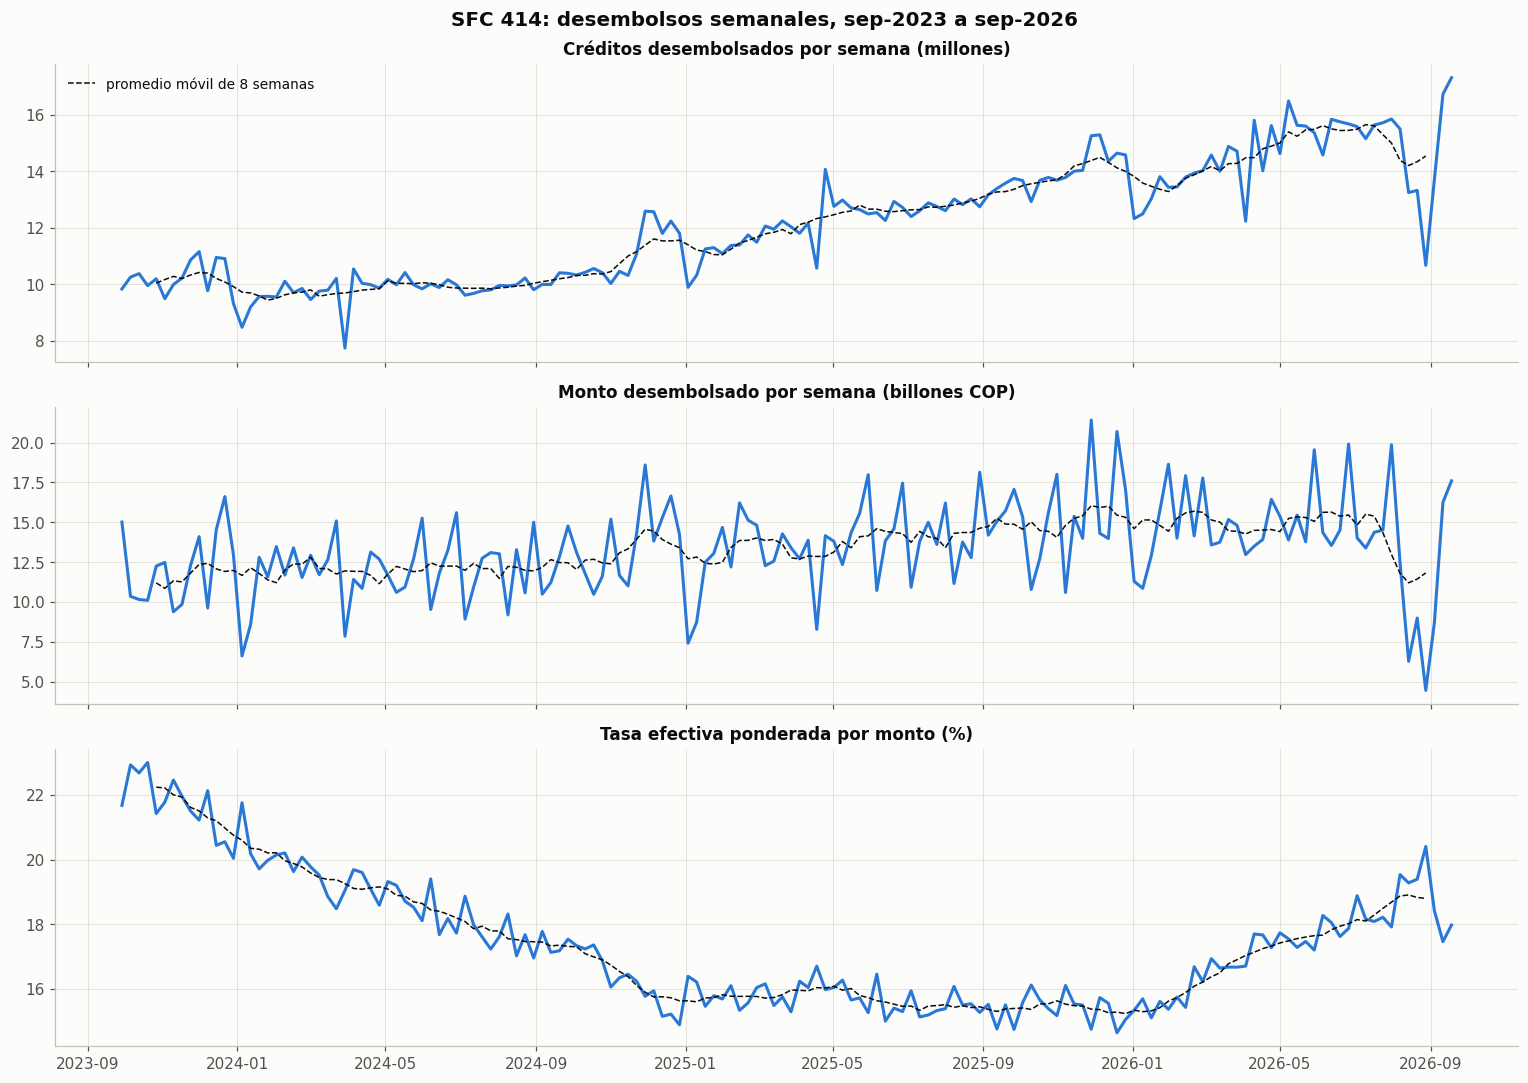

In [9]:
semanal = sfc.groupby("Fecha_Corte").agg(creditos=(NCRED, "sum"), monto=(MONTO, "sum"))
semanal["tasa"] = sfc.groupby("Fecha_Corte").apply(tasa_ponderada)

anual = pd.DataFrame({
    "semanas": semanas["semanas"],
    "créditos (millones)": sfc.groupby("anio")[NCRED].sum() / 1e6,
    "monto (billones COP)": sfc.groupby("anio")[MONTO].sum() / BILLON,
})
anual["créditos por semana (millones)"] = anual["créditos (millones)"] / anual["semanas"]
anual["monto por semana (billones COP)"] = anual["monto (billones COP)"] / anual["semanas"]
anual["monto por crédito (millones COP)"] = anual["monto (billones COP)"] / anual["créditos (millones)"]
anual["tasa ponderada (%)"] = sfc.groupby("anio").apply(tasa_ponderada)
anual["municipios con créditos"] = sfc.groupby("anio")["Codigo_Municipio"].nunique()
display(anual.style.format({"créditos (millones)": "{:,.1f}", "monto (billones COP)": "{:,.1f}",
                            "créditos por semana (millones)": "{:,.2f}", "monto por semana (billones COP)": "{:,.2f}",
                            "monto por crédito (millones COP)": "{:,.2f}", "tasa ponderada (%)": "{:.1f}",
                            "municipios con créditos": "{:,.0f}"}))

# Tres paneles uno debajo del otro, cada uno con su propio eje
fig, ejes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
series = [(semanal["creditos"] / 1e6, "Créditos desembolsados por semana (millones)"),
          (semanal["monto"] / BILLON, "Monto desembolsado por semana (billones COP)"),
          (semanal["tasa"], "Tasa efectiva ponderada por monto (%)")]
for ax, (s, titulo) in zip(ejes, series):
    ax.plot(s.index, s.values, color=PALETA[0], linewidth=2)
    ax.plot(s.index, s.rolling(8, center=True).mean(), color="#0b0b0b", linewidth=1, linestyle="--",
            label="promedio móvil de 8 semanas")
    ax.set_title(titulo, fontsize=11)
ejes[0].legend(loc="upper left", fontsize=9)
fig.suptitle("SFC 414: desembolsos semanales, sep-2023 a sep-2026", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

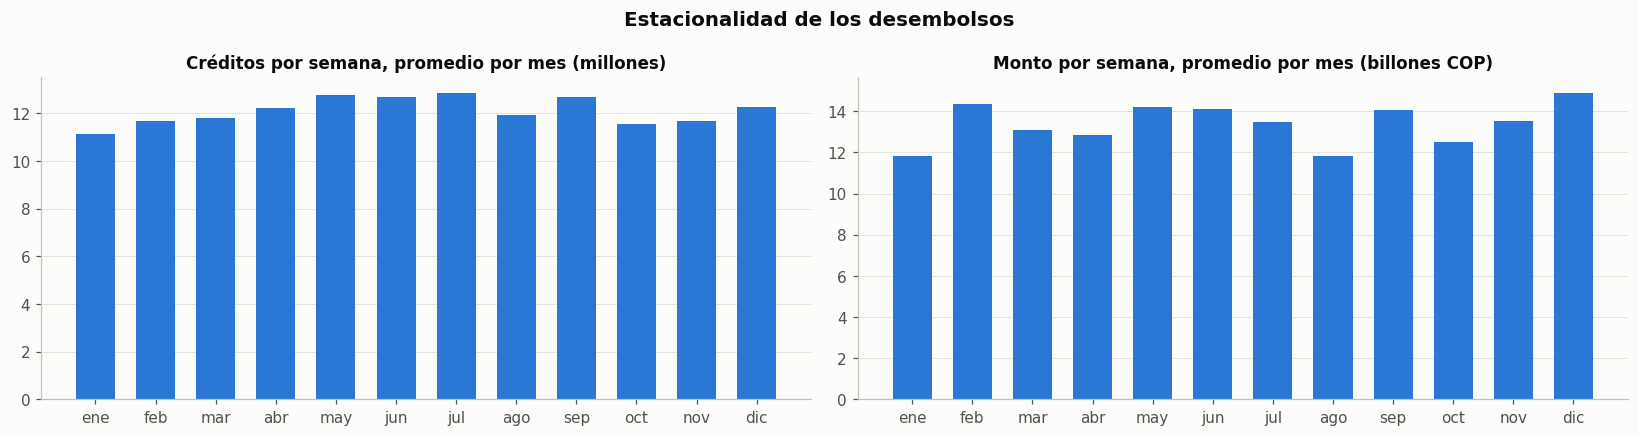

In [10]:
# Estacionalidad: promedio semanal por mes del año (se promedia sobre todas las semanas de ese mes en 2023–2026)
MESES = ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"]
por_mes = semanal.groupby(semanal.index.month)[["creditos", "monto"]].mean()
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 4))
a1.bar(MESES, por_mes["creditos"] / 1e6, color=PALETA[0], width=0.65)
a1.set_title("Créditos por semana, promedio por mes (millones)", fontsize=11)
a2.bar(MESES, por_mes["monto"] / BILLON, color=PALETA[0], width=0.65)
a2.set_title("Monto por semana, promedio por mes (billones COP)", fontsize=11)
for ax in (a1, a2):
    ax.grid(axis="x", visible=False)
fig.suptitle("Estacionalidad de los desembolsos", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

**Lectura:**
- **Más créditos:** el número de créditos por semana creció de unos 10 millones (2023–2024) a 12,8 millones (2025) y 14,6 millones (2026).
- **Monto:** creció menos, de unos 12 billones por semana a 14 billones. Por eso el monto promedio por crédito bajó de 1,2 millones a 0,97 millones: crece sobre todo el consumo, que tiene montos pequeños.
- **Tasa:** la tasa ponderada bajó de cerca del 23 % (oct-2023) a cerca del 15 % (2025) y volvió a subir en 2026, hasta el 18–19 %. A nivel semanal, las semanas con tasa más alta tienen menos monto y menos créditos (correlación de Spearman de −0,49 y −0,46, ver 2.6).
- **Variación:** de una semana a otra, el monto varía mucho. La última semana de cada mes promedia 15,4 billones, frente a 12,9 billones en las demás. La estacionalidad por mes es débil: diciembre, septiembre y febrero tienen algo más de monto y enero algo menos. El agosto bajo del gráfico se debe a las semanas incompletas de 2026 (ver abajo).
- **Semanas incompletas:** las semanas del 14-ago al 4-sep-2026 tienen menos filas de lo normal (entre 8.600 y 11.700, frente a unas 13.500) y el monto cae a la mitad. Parece un **reporte incompleto** de algunas entidades, no una caída real. Hay que tenerlo en cuenta si se usan las últimas semanas.
- **Cobertura:** todos los años hay desembolsos en unos 1.120 municipios.

### 2.2 Tipo de crédito

`Tipo_de_credito` es la modalidad de crédito de la Superintendencia Financiera: consumo, comercial (ordinario, preferencial o corporativo, especial y de tesorería), vivienda y **crédito productivo**. Esta última es la modalidad que reemplazó al microcrédito en 2023, y por eso "Microcredito" casi no aparece.

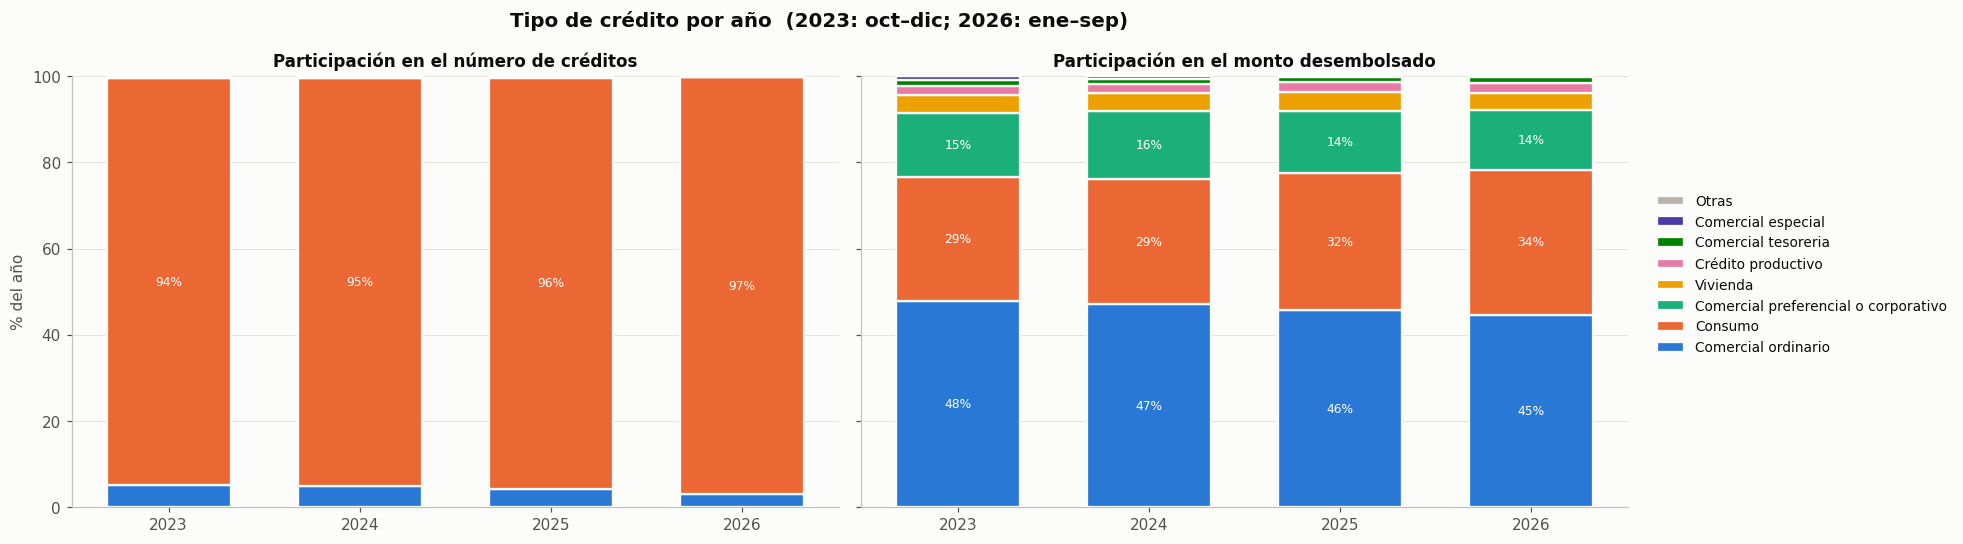

Todo el periodo


,créditos (millones),% créditos,monto (billones COP),% monto,monto por crédito (millones COP),tasa ponderada (%)
Tipo_de_credito,,,,,,
Comercial ordinario,78.91,4.18,959.3,46.00,12.16,16.7
Consumo,"1,802.15",95.49,651.2,31.22,0.36,19.3
Comercial preferencial o corporativo,0.62,0.03,306.8,14.71,492.90,13.3
Vivienda,0.63,0.03,86.7,4.16,137.49,12.8
Crédito productivo,4.69,0.25,46.3,2.22,9.87,35.8
Comercial tesoreria,0.24,0.01,27.4,1.32,113.07,11.8
Comercial especial,0.07,0.00,7.7,0.37,116.43,12.9
Microcredito,0.00,0.00,0.0,0.00,34.50,20.6


In [11]:
_ = figura_por_anio("Tipo_de_credito", "Tipo de crédito por año")

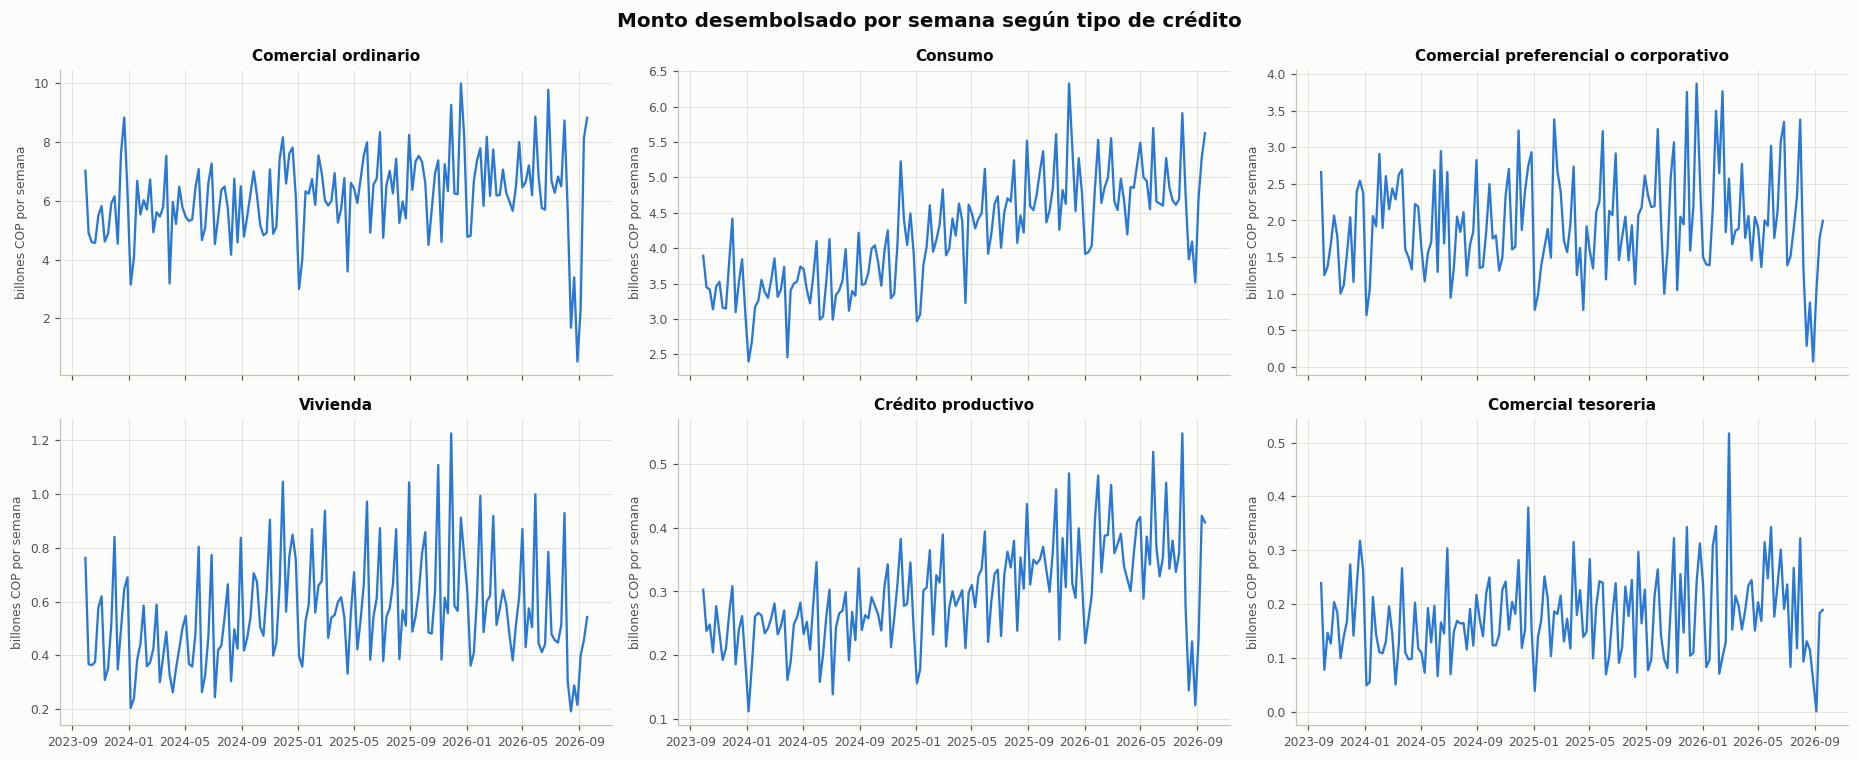

In [12]:
# Monto semanal de cada tipo de credito (paneles con su propio eje; los tipos con menos de 1% del monto se omiten)
tipos = perfil("Tipo_de_credito").query("`% monto` >= 1").index
fig, ejes = plt.subplots(2, 3, figsize=(17, 7), sharex=True)
for ax, tipo in zip(ejes.flat, tipos):
    d = sfc[sfc["Tipo_de_credito"] == tipo].groupby("Fecha_Corte")[[MONTO, NCRED]].sum()
    ax.plot(d.index, d[MONTO] / BILLON, color=PALETA[0], linewidth=1.5)
    ax.set_title(f"{tipo}", fontsize=10)
    ax.set_ylabel("billones COP por semana", fontsize=8)
    ax.tick_params(labelsize=8)
for ax in ejes.flat[len(tipos):]:
    ax.set_visible(False)
fig.suptitle("Monto desembolsado por semana según tipo de crédito", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

**Lectura:**
- **Consumo:** es casi todo el número de créditos (95,5 %, y subiendo del 94 % al 97 %), pero solo el 31 % del monto. Su monto promedio es de 360 mil pesos, lo que sugiere que incluye muchos desembolsos pequeños, como compras con tarjeta o cupos rotativos.
- **Comercial:** el crédito comercial se lleva la mayor parte del dinero. El comercial ordinario tiene el 46 % del monto, con 12 millones por crédito. El preferencial o corporativo tiene el 15 % del monto con apenas el 0,03 % de los créditos, a casi 500 millones por crédito.
- **Crédito productivo:** es la modalidad más cercana al crédito rural y agropecuario. Aparece en el 44 % de las filas porque se desembolsa en casi todos los municipios, pero es solo el 2,2 % del monto (10 millones por crédito). Tiene la tasa más alta, de 36 % a 40 %.
- **Tasas por modalidad:** después del productivo vienen el consumo (cerca del 20 %) y el comercial ordinario (15–17 %). Corporativo, tesorería y vivienda tienen las tasas más bajas, entre 11 % y 14 %. Todas bajaron entre 2023 y 2025 y subieron en 2026, salvo el productivo, que se mantiene entre 32 % y 40 %.

### 2.3 Tipo de garantía

Los créditos pueden estar respaldados por una garantía idónea o no idónea del deudor, o por un fondo de garantías: el **FAG** (Fondo Agropecuario de Garantías, el mismo de FINAGRO), el **FNG** (Fondo Nacional de Garantías) o el **FGA** (Fondo de Garantías de Antioquia). También pueden no tener garantía. FNG y FGA se unen en una sola categoría porque hasta sep-2025 se reportaban juntos.

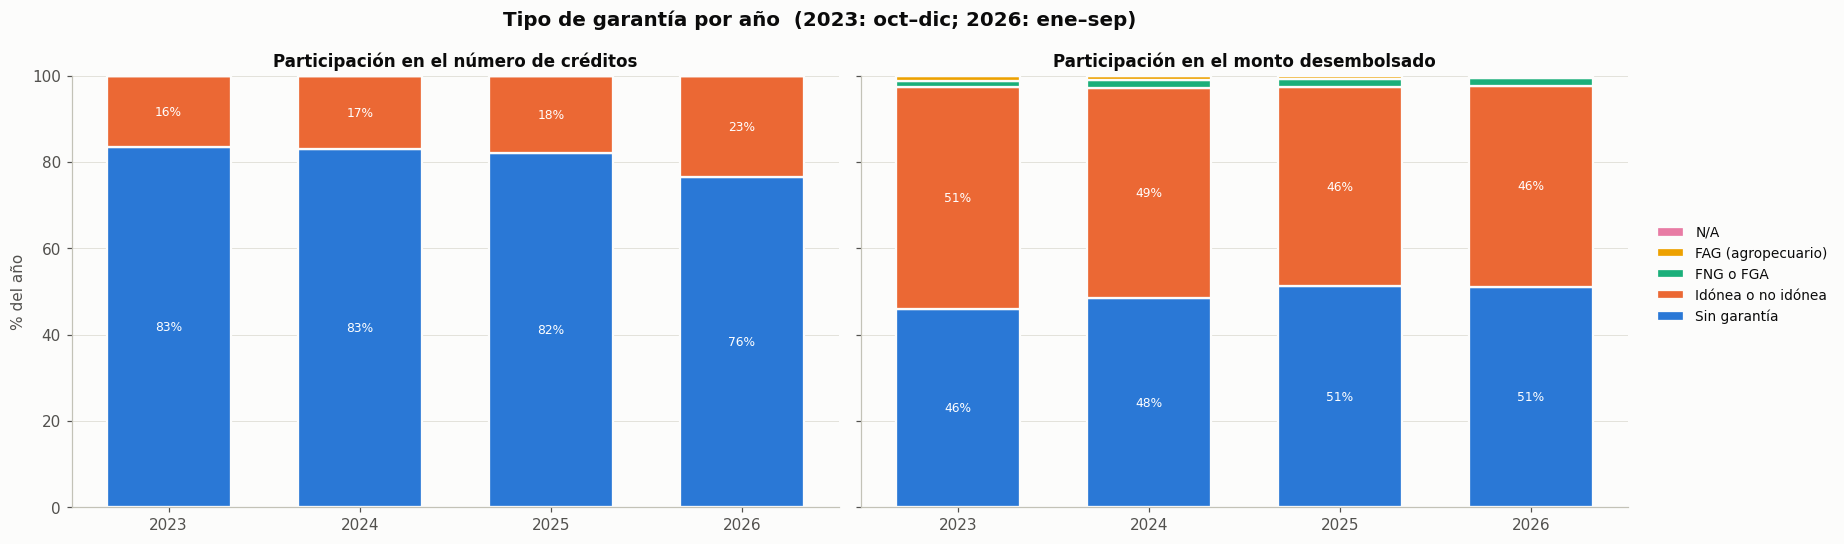

Todo el periodo


,créditos (millones),% créditos,monto (billones COP),% monto,monto por crédito (millones COP),tasa ponderada (%)
garantia,,,,,,
Sin garantía,"1,525.24",80.82,"1,041.0",49.92,0.68,18.5
Idónea o no idónea,359.39,19.04,989.4,47.44,2.75,15.6
FNG o FGA,1.92,0.10,36.4,1.75,18.99,25.8
FAG (agropecuario),0.73,0.04,17.9,0.86,24.50,14.8
N/A,0.04,0.00,0.8,0.04,17.99,24.2


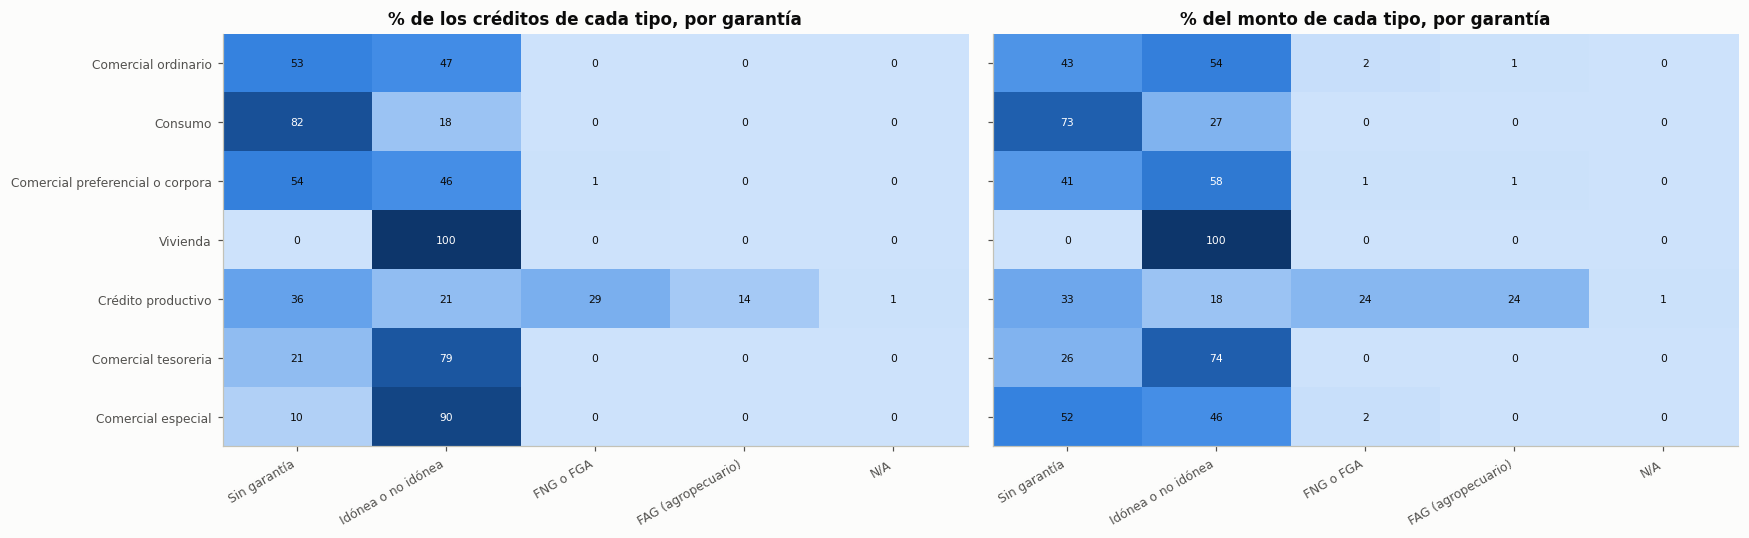

In [13]:
_ = figura_por_anio("garantia", "Tipo de garantía por año")

# Que garantia usa cada tipo de credito: % del monto de cada tipo de credito (filas suman 100)
pv = sfc.pivot_table(index="Tipo_de_credito", columns="garantia", values=MONTO, aggfunc="sum", observed=True).fillna(0)
pv = pv.loc[perfil("Tipo_de_credito").index.intersection(pv.index).drop("Microcredito", errors="ignore")]
pv = pv[pv.sum().sort_values(ascending=False).index]
pv_n = sfc.pivot_table(index="Tipo_de_credito", columns="garantia", values=NCRED, aggfunc="sum", observed=True).fillna(0)
pv_n = pv_n.loc[pv.index, pv.columns]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(16, 5))
mapa_calor(a1, pv_n.div(pv_n.sum(axis=1), axis=0) * 100, "% de los créditos de cada tipo, por garantía", fmt="{:.0f}")
mapa_calor(a2, pv.div(pv.sum(axis=1), axis=0) * 100, "% del monto de cada tipo, por garantía", fmt="{:.0f}")
a2.tick_params(labelleft=False)
fig.tight_layout()
plt.show()

**Lectura:**
- **Garantía propia o ninguna:** la mayoría de los créditos no tiene garantía (81 % de los créditos y 50 % del monto) o tiene una garantía idónea o no idónea del deudor (19 % y 47 %). Los fondos de garantías pesan poco en el total: 2,6 % del monto.
- **Crédito productivo:** es la modalidad que más usa fondos de garantías. El 24 % de su monto está respaldado por el FNG o el FGA y otro 24 % por el **FAG**, el fondo agropecuario de FINAGRO.
- **El FAG abarata:** el crédito productivo con FAG tiene una tasa ponderada del **14,4 %**, frente a entre 40 % y 45 % con otras garantías o sin garantía. El FAG va ligado al crédito de fomento agropecuario, que es justamente el que registra FINAGRO.
- **Vivienda:** el 100 % tiene garantía idónea, que es la hipoteca.

### 2.4 Tipo de persona y sexo

`Sexo` solo aplica a personas naturales. Para las jurídicas viene como "No aplica", así que la comparación por sexo se hace solo con personas naturales.

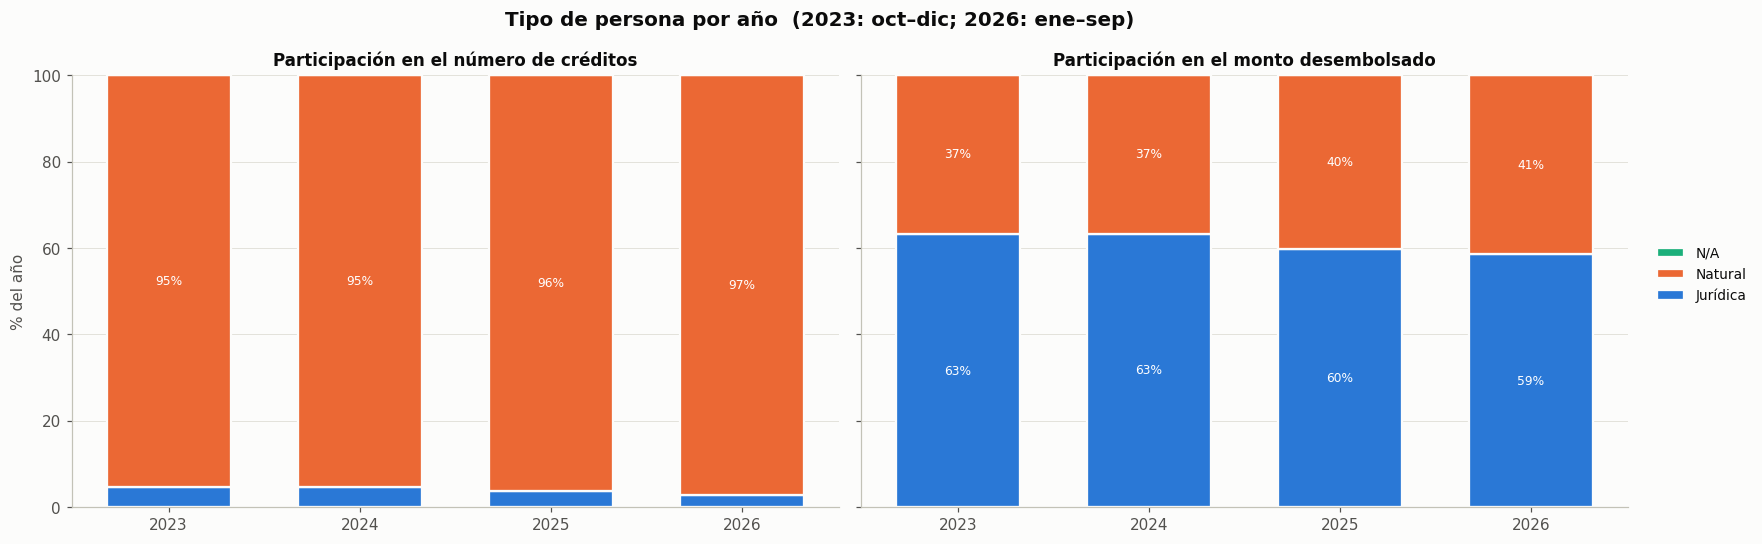

Todo el periodo


,créditos (millones),% créditos,monto (billones COP),% monto,monto por crédito (millones COP),tasa ponderada (%)
Tipo_de_persona,,,,,,
Jurídica,71.53,3.79,"1,269.7",60.88,17.75,15.7
Natural,"1,815.78",96.21,815.8,39.12,0.45,19.5
N/A,0.00,0.00,0.0,0.00,"1,269.12",15.9


Tipo_de_credito,Consumo,Crédito productivo,Comercial ordinario,Vivienda,Comercial preferencial o corporativo,Comercial tesoreria,Comercial especial,Microcredito
Tipo_de_persona,,,,,,,,
Natural,79.8,5.5,3.9,10.6,0.1,0.0,0.0,0.0
Jurídica,0.0,0.1,73.0,0.0,24.1,2.2,0.6,0.0


In [14]:
_ = figura_por_anio("Tipo_de_persona", "Tipo de persona por año")

# Mezcla de tipos de credito dentro de cada tipo de persona (% del monto)
mezcla = sfc.pivot_table(index="Tipo_de_persona", columns="Tipo_de_credito", values=MONTO, aggfunc="sum",
                         observed=True).fillna(0).loc[["Natural", "Jurídica"]]
(mezcla.div(mezcla.sum(axis=1), axis=0) * 100).style.format("{:.1f}").set_caption(
    "% del monto de cada tipo de persona, por tipo de crédito")

Personas naturales, todo el periodo


,créditos (millones),% créditos,monto (billones COP),% monto,monto por crédito (millones COP),tasa ponderada (%)
Sexo,,,,,,
Masculino,964.86,53.14,454.3,55.69,0.47,19.2
Femenino,850.57,46.84,361.4,44.30,0.42,20.0
No binario,0.36,0.02,0.1,0.01,0.27,20.4
Trans,0.00,0.00,0.0,0.00,0.60,31.1


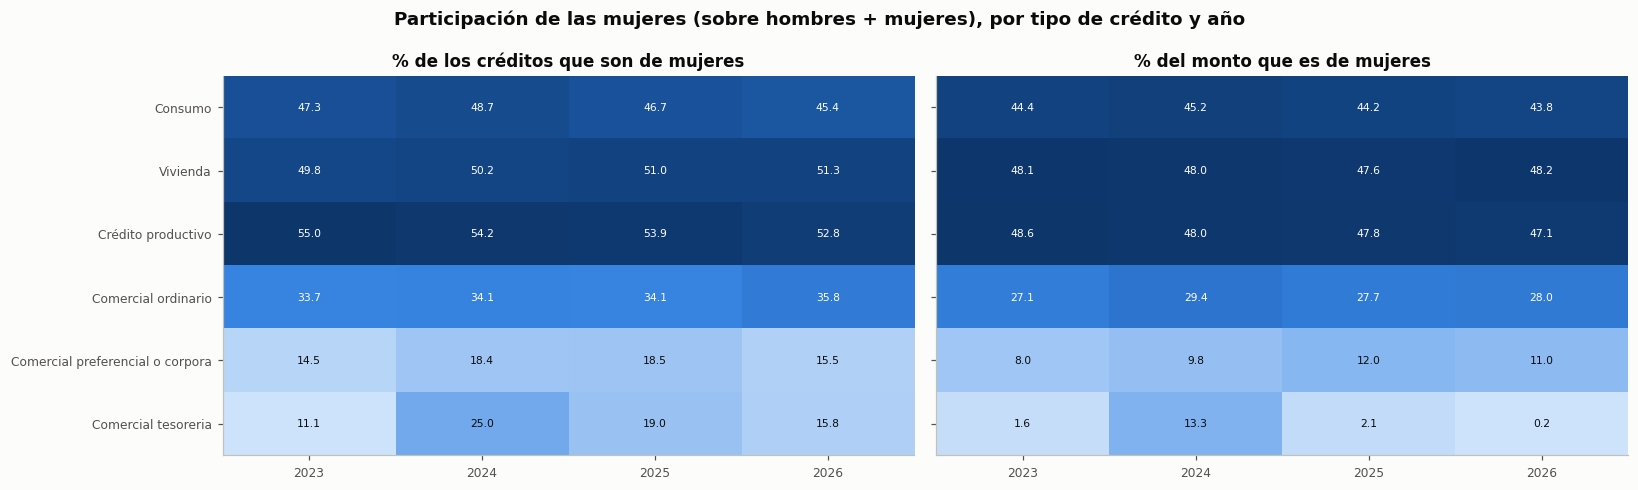

In [15]:
nat = sfc[sfc["Tipo_de_persona"] == "Natural"]
print("Personas naturales, todo el periodo")
display(perfil("Sexo", nat).style.format(FORMATO_PERFIL))

# Participacion de las mujeres por tipo de credito y año (solo Femenino / Masculino)
fm = nat[nat["Sexo"].isin(["Femenino", "Masculino"])]
mujer = lambda col: (fm[col].where(fm["Sexo"] == "Femenino", 0)
                     .groupby([fm["Tipo_de_credito"].astype("object"), fm["anio"]]).sum()
                     / fm[col].groupby([fm["Tipo_de_credito"].astype("object"), fm["anio"]]).sum() * 100).unstack()
pm_n, pm_m = mujer(NCRED), mujer(MONTO)
orden = [t for t in perfil("Tipo_de_credito", nat).index
         if t in pm_n.index and t != "Microcredito" and pm_n.loc[t].sum() > 0]  # "Comercial especial" no tiene mujeres
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 4.5))
mapa_calor(a1, pm_n.loc[orden], "% de los créditos que son de mujeres", fmt="{:.1f}")
mapa_calor(a2, pm_m.loc[orden], "% del monto que es de mujeres", fmt="{:.1f}")
for ax in (a1, a2):
    ax.set_xticks(range(pm_n.shape[1]), [str(c) for c in pm_n.columns], rotation=0, ha="center")
a2.tick_params(labelleft=False)
fig.suptitle("Participación de las mujeres (sobre hombres + mujeres), por tipo de crédito y año",
             fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

**Lectura:**
- **Personas jurídicas:** son el 3,8 % de los créditos pero el 61 % del monto, con 17,8 millones por crédito frente a 0,45 millones de las personas naturales. Su monto es casi todo crédito comercial: ordinario 73 % y corporativo 24 %.
- **Personas naturales:** su monto es sobre todo consumo (80 %), seguido de vivienda (10,6 %), crédito productivo (5,5 %) y comercial ordinario (3,9 %).
- **Sexo (personas naturales):** las mujeres tienen el 46,8 % de los créditos y el 44,3 % del monto. Su crédito promedio es algo menor (0,42 frente a 0,47 millones) y su tasa algo mayor (20,0 % frente a 19,2 %).
- **Sexo por modalidad:** en **crédito productivo las mujeres son mayoría en número** (53–55 % de los créditos) y tienen cerca del 48 % del monto. En vivienda están a la par y en consumo tienen entre 45 % y 49 %. En el crédito comercial su participación es mucho menor: 34–36 % de los créditos del ordinario y 14–19 % del corporativo, y todavía menos en monto.

### 2.5 Ubicación

Se mira en cuatro niveles: región, departamento, municipio y tipo de municipio (categoría de ruralidad del DNP, rural/urbano y PDET). El municipio es donde la entidad reporta el desembolso.

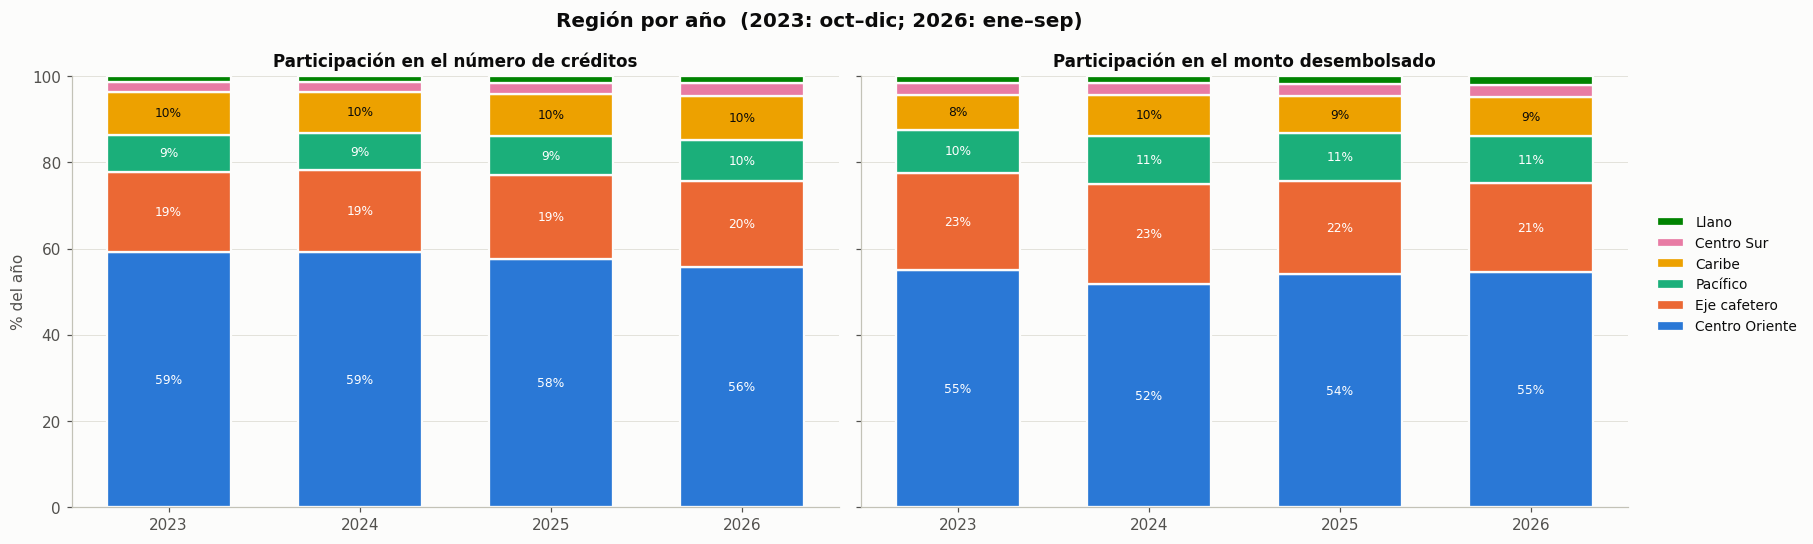

Todo el periodo


,créditos (millones),% créditos,monto (billones COP),% monto,monto por crédito (millones COP),tasa ponderada (%)
region_c,,,,,,
Centro Oriente,"1,088.07",57.65,"1,116.7",53.55,1.03,17.0
Eje cafetero,364.91,19.33,457.9,21.96,1.25,16.6
Pacífico,171.54,9.09,227.4,10.90,1.33,17.7
Caribe,184.96,9.80,189.0,9.06,1.02,18.0
Centro Sur,49.37,2.62,58.8,2.82,1.19,19.3
Llano,28.48,1.51,35.7,1.71,1.25,20.4


In [16]:
_ = figura_por_anio("region_c", "Región por año")

,créditos (millones),% créditos,monto (billones COP),% monto,monto por crédito (millones COP),tasa ponderada (%)
departamento,,,,,,
"Bogotá, D.C.",900.60,47.72,952.9,45.69,1.06,16.8
Antioquia,293.89,15.57,388.5,18.63,1.32,16.4
Valle del Cauca,148.80,7.88,198.7,9.53,1.34,17.1
Atlántico,85.09,4.51,88.8,4.26,1.04,16.9
Santander,65.12,3.45,63.0,3.02,0.97,17.6
Cundinamarca,77.33,4.10,61.0,2.93,0.79,18.1
Bolívar,39.38,2.09,36.9,1.77,0.94,18.3
Risaralda,32.67,1.73,31.9,1.53,0.98,17.6
Tolima,26.07,1.38,28.7,1.38,1.10,18.5


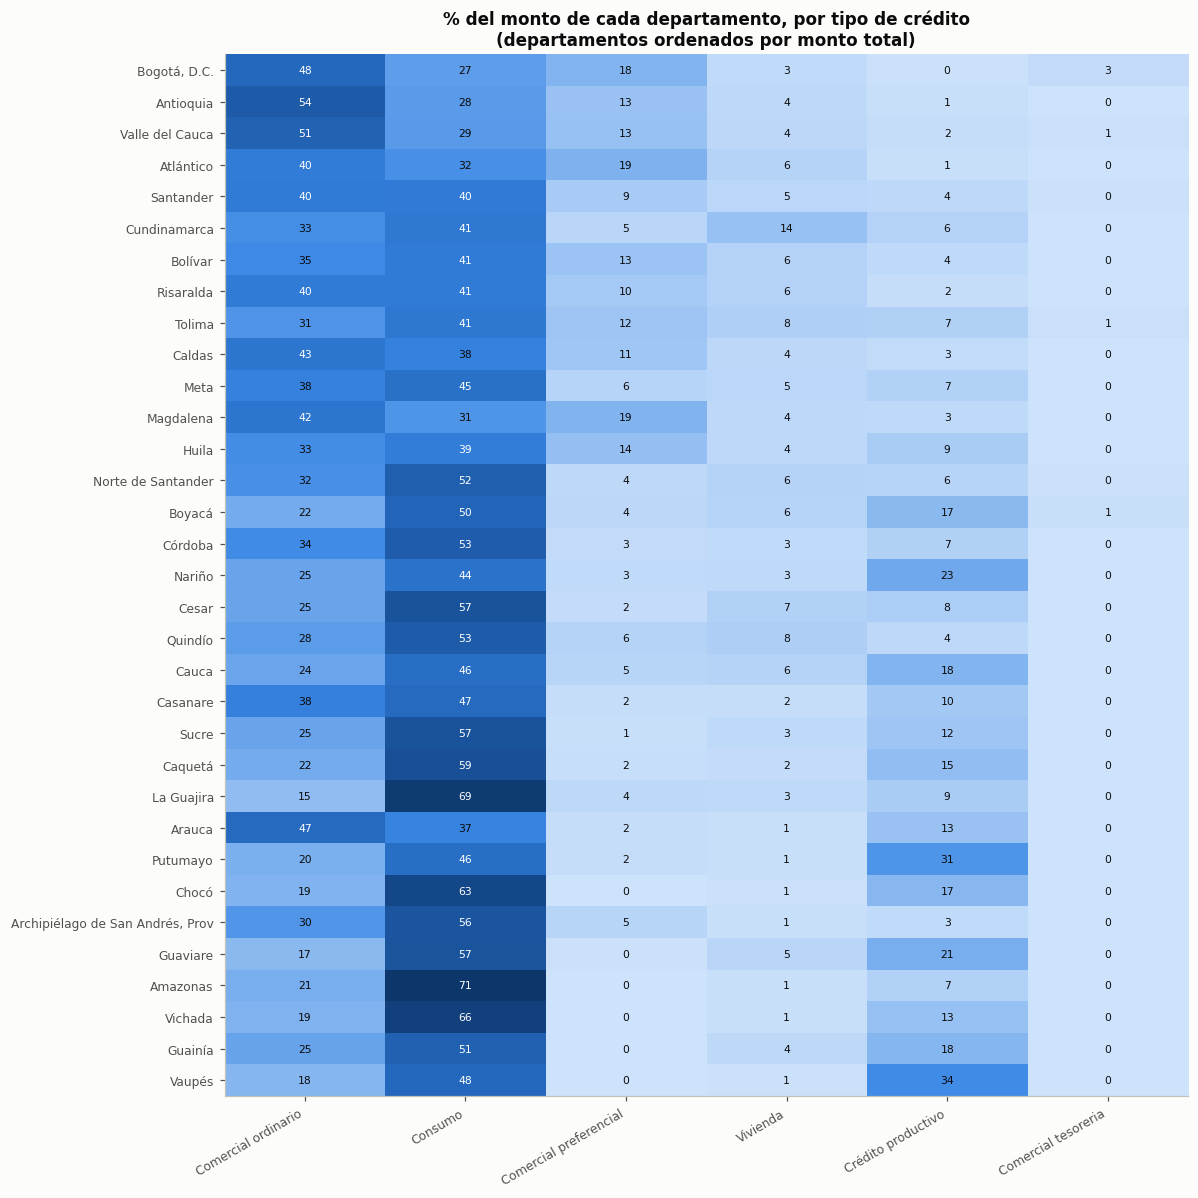

In [17]:
dep = perfil("departamento")
display(dep.style.format(FORMATO_PERFIL).set_caption("Departamentos ordenados por monto (todo el periodo)"))

# Que tipos de credito se desembolsan en cada departamento (% del monto del departamento; filas suman 100)
tipos_principales = perfil("Tipo_de_credito").index[:6]
mz = sfc.pivot_table(index="departamento", columns="Tipo_de_credito", values=MONTO, aggfunc="sum", observed=True).fillna(0)
mz_pct = (mz.div(mz.sum(axis=1), axis=0) * 100)[tipos_principales].loc[dep.index]
fig, ax = plt.subplots(figsize=(11, 11))
mapa_calor(ax, mz_pct, "% del monto de cada departamento, por tipo de crédito\n(departamentos ordenados por monto total)",
           fmt="{:.0f}")
fig.tight_layout()
plt.show()

In [18]:
mun = perfil(["Codigo_Municipio"])
nombres = (sfc.drop_duplicates("Codigo_Municipio").set_index("Codigo_Municipio")[["nombre_municipio", "departamento"]]
           .astype("object"))
mun.insert(0, "municipio", [f"{nombres.at[c, 'nombre_municipio']} ({nombres.at[c, 'departamento']})" for c in mun.index])
display(mun.head(20).style.format(FORMATO_PERFIL).set_caption("Los 20 municipios con más monto"))

# Concentracion: que % de los creditos y del monto se llevan el 1%, 10% y 50% de municipios con mas creditos (o monto)
n_mun = len(mun)
acum_n = mun["% créditos"].sort_values(ascending=False).cumsum().values
acum_m = mun["% monto"].sort_values(ascending=False).cumsum().values
conc = pd.DataFrame({f"{p}% de municipios ({int(np.ceil(n_mun * p / 100))})":
                     {"% de los créditos": acum_n[int(np.ceil(n_mun * p / 100)) - 1],
                      "% del monto": acum_m[int(np.ceil(n_mun * p / 100)) - 1]}
                     for p in (1, 10, 50)}).T
print(f"{n_mun:,} municipios con desembolsos en el periodo")
conc.style.format("{:.1f}")

,municipio,créditos (millones),% créditos,monto (billones COP),% monto,monto por crédito (millones COP),tasa ponderada (%)
Codigo_Municipio,,,,,,,
11001,"Bogotá, D.C. (Bogotá, D.C.)",900.60,47.72,952.9,45.69,1.06,16.8
05001,Medellín (Antioquia),188.74,10.00,285.3,13.68,1.51,16.4
76001,Cali (Valle del Cauca),115.48,6.12,149.1,7.15,1.29,17.0
08001,Barranquilla (Atlántico),74.42,3.94,80.1,3.84,1.08,16.7
68001,Bucaramanga (Santander),38.09,2.02,38.6,1.85,1.01,16.9
13001,Cartagena (Bolívar),35.93,1.90,32.9,1.58,0.92,17.9
05266,Envigado (Antioquia),32.62,1.73,29.5,1.41,0.90,14.9
66001,Pereira (Risaralda),26.01,1.38,26.1,1.25,1.00,17.5
17001,Manizales (Caldas),18.50,0.98,21.4,1.03,1.16,16.9


1,123 municipios con desembolsos en el periodo


,% de los créditos,% del monto
1% de municipios (12),78.8,80.3
10% de municipios (113),96.5,96.0
50% de municipios (562),99.5,99.4


Categoría de ruralidad


,créditos (millones),% créditos,monto (billones COP),% monto,monto por crédito (millones COP),tasa ponderada (%)
ruralidad,,,,,,
Ciudades y aglomeraciones,"1,799.61",95.35,"1,977.6",94.83,1.10,17.0
Intermedio,63.31,3.35,72.8,3.49,1.15,21.2
Rural,17.70,0.94,24.8,1.19,1.40,21.2
Rural disperso,6.70,0.35,10.3,0.49,1.54,20.9
Sin dato,0.00,0.00,0.0,0.00,18.82,16.9


Rural / urbano


,créditos (millones),% créditos,monto (billones COP),% monto,monto por crédito (millones COP),tasa ponderada (%)
Rural_Urbano,,,,,,
Urbano,"1,862.92",98.71,"2,050.4",98.32,1.10,17.1
Rural + Disperso,24.40,1.29,35.1,1.68,1.44,21.1


PDET


,créditos (millones),% créditos,monto (billones COP),% monto,monto por crédito (millones COP),tasa ponderada (%)
PDET_Nom,,,,,,
NO PDET,"1,841.16",97.55,"2,028.8",97.28,1.10,17.1
PDET,46.16,2.45,56.6,2.72,1.23,20.1


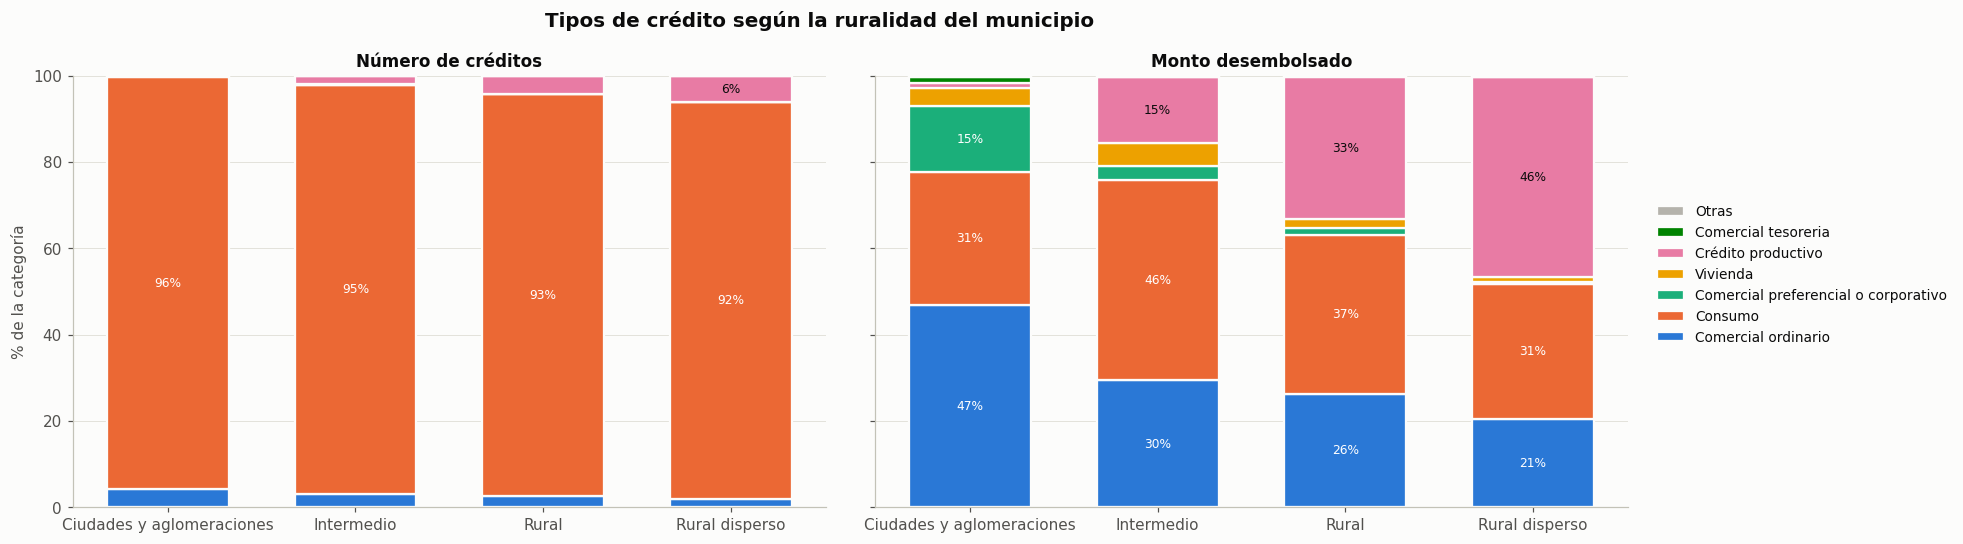

In [19]:
ORDEN_RURAL = ["Ciudades y aglomeraciones", "Intermedio", "Rural", "Rural disperso"]
for col, titulo in [("ruralidad", "Categoría de ruralidad"), ("Rural_Urbano", "Rural / urbano"), ("PDET_Nom", "PDET")]:
    print(titulo)
    display(perfil(col).style.format(FORMATO_PERFIL))

# Mezcla de tipos de credito en cada categoria de ruralidad: numero y monto (columnas suman 100)
s, tops = agrupar_top(sfc["Tipo_de_credito"], 6)
mez_n = sfc[NCRED].groupby([s, sfc["ruralidad"].astype("object")]).sum().unstack().reindex(tops + ["Otras"])[ORDEN_RURAL]
mez_m = sfc[MONTO].groupby([s, sfc["ruralidad"].astype("object")]).sum().unstack().reindex(tops + ["Otras"])[ORDEN_RURAL]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
apiladas(a1, mez_n.fillna(0), "Número de créditos", ylabel="% de la categoría")
apiladas(a2, mez_m.fillna(0), "Monto desembolsado", ylabel="")
h, l = a1.get_legend_handles_labels()
fig.legend(h[::-1], l[::-1], loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=9)
fig.suptitle("Tipos de crédito según la ruralidad del municipio", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

**Lectura:**
- **Concentración urbana extrema:** Bogotá sola tiene el 47,7 % de los créditos y el 45,7 % del monto. Le siguen Medellín (13,7 % del monto), Cali (7,2 %) y Barranquilla (3,8 %). El 1 % de los municipios (12) reúne el 79 % de los créditos y el 80 % del monto, y el 10 % (113) reúne el 96 %. Las ciudades y aglomeraciones tienen el 95 % del crédito, los municipios rurales y rurales dispersos solo el 1,7 % del monto, y los PDET el 2,7 %.
- **Composición distinta en lo rural:** aunque el consumo es más del 92 % de los créditos en todo tipo de municipio, **el crédito productivo pasa del 1 % del monto en las ciudades al 15 % en los intermedios, al 33 % en los rurales y al 46 % en los rurales dispersos**. El comercial y el corporativo, en cambio, se concentran en las ciudades.
- **Departamentos:** en Bogotá, Antioquia y Valle más de la mitad del monto es comercial. En los departamentos periféricos domina el consumo y **el crédito productivo gana peso**: Vaupés 34 %, Putumayo 31 %, Nariño 23 %, Guaviare 21 %, Cauca y Guainía 18 %, Boyacá y Chocó 17 % y Caquetá 15 % del monto. Varios de ellos son departamentos amazónicos con alta deforestación.
- **Tasas por ruralidad:** los municipios rurales pagan una tasa ponderada más alta (cerca del 21 %, frente al 17 % en las ciudades), sobre todo porque en ellos pesa más el crédito productivo. Dentro del crédito productivo pasa lo contrario: la tasa es más baja en los municipios rurales dispersos (24 %) que en las ciudades (42 %), probablemente por el mayor uso del FAG y de líneas de fomento. Los departamentos periféricos (Putumayo, Vaupés, Nariño, Cauca) tienen las tasas ponderadas más altas, entre 21 % y 26 %.
- **Frente a FINAGRO:** en FINAGRO, cerca del 85 % de los desembolsos va a municipios intermedios, rurales y rurales dispersos. En SFC 414 el crédito se concentra en las ciudades porque reúne todo el crédito del sistema financiero, no solo el agropecuario. Para el vínculo con deforestación, lo más útil de esta tabla es el **crédito productivo** en municipios rurales y el crédito con **garantía FAG**.

### 2.6 Tasa de interés y relación entre las variables numéricas

Se mira cómo cambia la tasa según el tipo de crédito, la garantía, la ruralidad y el sexo. También se mira cómo se relacionan entre sí el monto, el número de créditos, el monto por crédito y la tasa. Para esa relación se usa la **correlación de Spearman**, que se basa en el orden de los valores y no se deja arrastrar por los valores extremos.

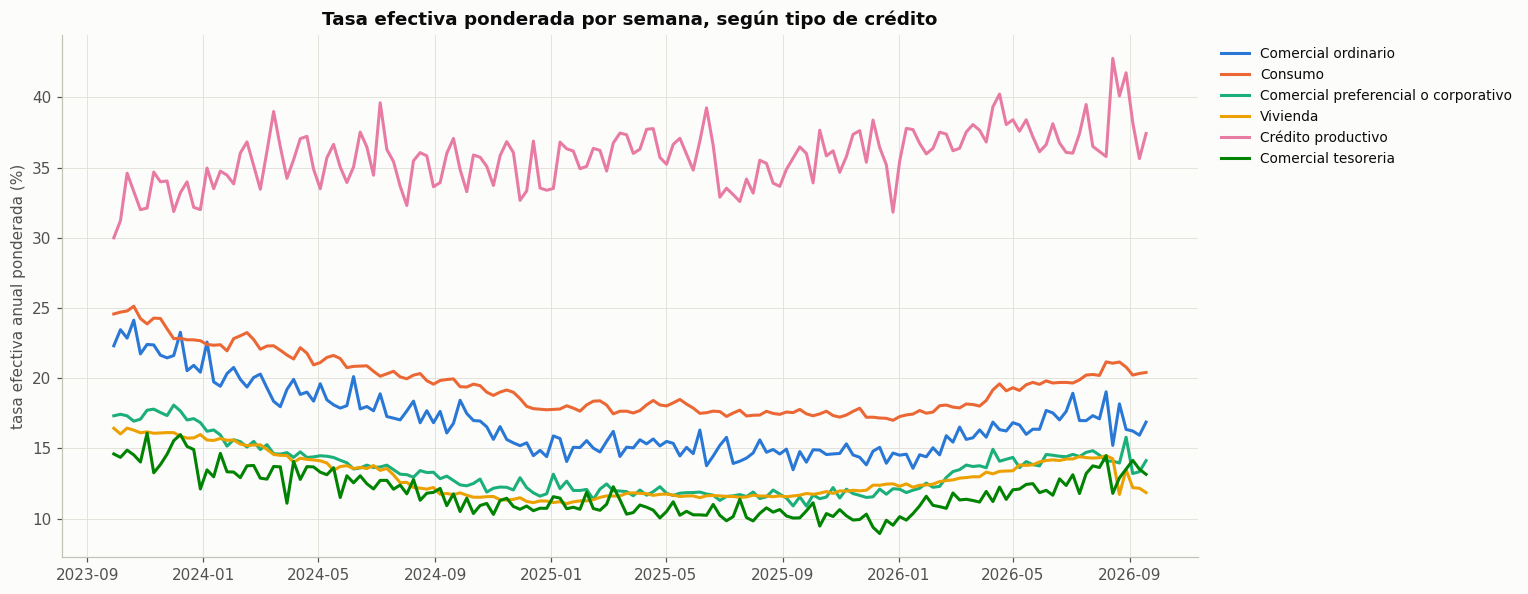

garantia,FAG (agropecuario),FNG o FGA,Idónea o no idónea,N/A,Sin garantía
Tipo_de_credito,,,,,
Comercial ordinario,16.6,17.2,15.3,15.1,18.5
Consumo,17.2,26.6,19.7,25.3,19.2
Comercial preferencial o corporativo,13.2,14.7,13.4,12.6,13.2
Vivienda,—,12.7,12.8,14.6,4.9
Crédito productivo,14.4,44.3,39.6,45.2,42.9
Comercial tesoreria,—,14.3,11.3,—,13.0


ruralidad,Ciudades y aglomeraciones,Intermedio,Rural,Rural disperso
Tipo_de_credito,,,,
Comercial ordinario,16.7,17.9,17.8,17.5
Consumo,19.3,20.0,19.7,19.4
Comercial preferencial o corporativo,13.3,12.6,14.5,14.8
Vivienda,12.8,12.9,12.9,12.9
Crédito productivo,41.8,35.8,26.4,23.8
Comercial tesoreria,11.8,14.0,18.6,12.4


In [20]:
# Tasa ponderada semanal por tipo de credito (una linea por tipo; los mismos colores que en las secciones anteriores)
tipos = perfil("Tipo_de_credito").query("`% monto` >= 1").index
fig, ax = plt.subplots(figsize=(14, 5.5))
for i, tipo in enumerate(tipos):
    d = sfc[sfc["Tipo_de_credito"] == tipo]
    s = d.groupby("Fecha_Corte").apply(tasa_ponderada)
    ax.plot(s.index, s.values, color=PALETA[i], linewidth=2, label=tipo)
ax.set_ylabel("tasa efectiva anual ponderada (%)")
ax.set_title("Tasa efectiva ponderada por semana, según tipo de crédito", fontsize=12)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9)
fig.tight_layout()
plt.show()

# Tasa ponderada por garantia y por ruralidad, dentro de cada tipo de credito (cada celda: tasa del cruce)
for col in ["garantia", "ruralidad"]:
    pv = (sfc[sfc["Tipo_de_credito"].isin(tipos)]
          .groupby([sfc["Tipo_de_credito"].astype("object"), sfc[col].astype("object")]).apply(tasa_ponderada).unstack())
    display(pv.loc[tipos].style.format("{:.1f}", na_rep="—")
            .set_caption(f"Tasa ponderada (%) por tipo de crédito y {col}"))

Correlación de Spearman entre filas (segmento x municipio x semana)


,monto,número de créditos,monto por crédito,tasa
monto,1.00,0.49,0.49,-0.21
número de créditos,0.49,1.00,-0.42,-0.14
monto por crédito,0.49,-0.42,1.00,-0.02
tasa,-0.21,-0.14,-0.02,1.00


Correlación de Spearman entre semanas (totales nacionales)


,monto,número de créditos,monto por crédito,tasa
monto,1.00,0.54,0.55,-0.49
número de créditos,0.54,1.00,-0.34,-0.46
monto por crédito,0.55,-0.34,1.00,-0.13
tasa,-0.49,-0.46,-0.13,1.00


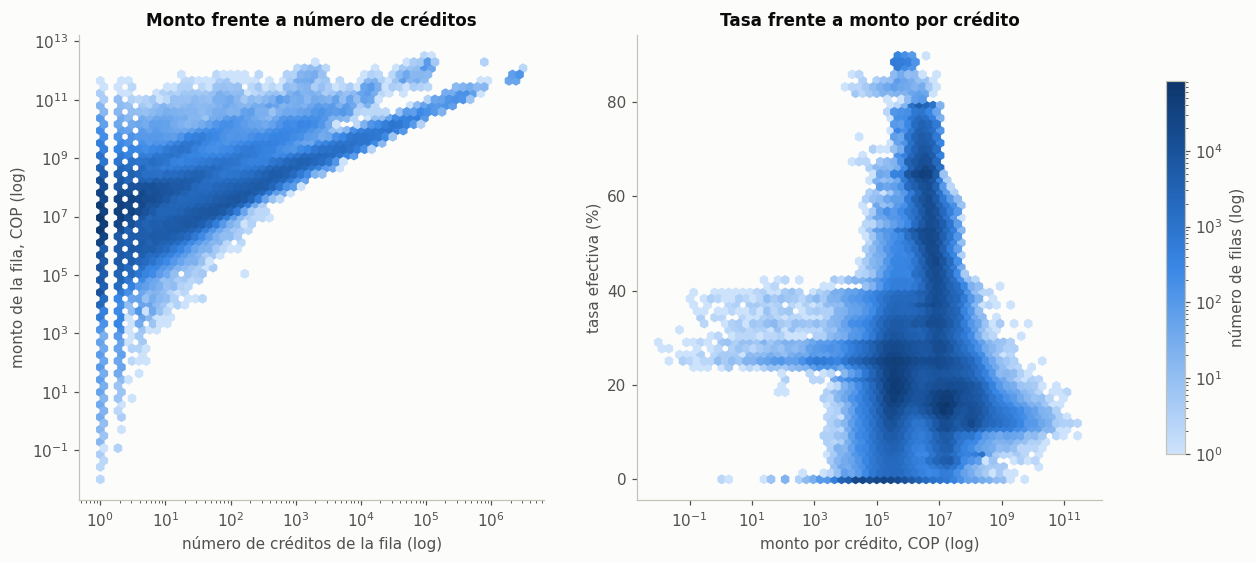

,créditos (millones),% créditos,monto (billones COP),% monto,monto por crédito (millones COP),tasa ponderada (%)
monto por crédito,,,,,,
< 100 mil,0.46,0.02,0.0,0.00,0.06,16.5
100 mil–1 M,"1,795.60",95.14,637.3,30.56,0.35,19.3
1–5 M,22.56,1.20,46.7,2.24,2.07,22.8
5–20 M,59.53,3.15,712.7,34.18,11.97,17.9
20–100 M,7.78,0.41,236.7,11.35,30.44,15.8
100 M–1.000 M,1.35,0.07,336.9,16.15,250.36,13.6
> 1.000 M,0.04,0.00,115.1,5.52,"2,719.73",13.1


In [21]:
# Correlaciones de Spearman entre las variables numericas, a nivel de fila y a nivel semanal nacional
cols = [MONTO, NCRED, "monto_por_credito", TASA]
nombres_cortos = {MONTO: "monto", NCRED: "número de créditos", "monto_por_credito": "monto por crédito", TASA: "tasa"}
corr_filas = sfc[cols].corr(method="spearman").rename(index=nombres_cortos, columns=nombres_cortos)
semanal["monto_por_credito"] = semanal["monto"] / semanal["creditos"]
corr_sem = (semanal[["monto", "creditos", "monto_por_credito", "tasa"]].corr(method="spearman")
            .set_axis(list(nombres_cortos.values()), axis=0).set_axis(list(nombres_cortos.values()), axis=1))
print("Correlación de Spearman entre filas (segmento x municipio x semana)")
display(corr_filas.style.format("{:.2f}"))
print("Correlación de Spearman entre semanas (totales nacionales)")
display(corr_sem.style.format("{:.2f}"))

# Monto frente a numero de creditos y tasa frente a monto por credito (hexbin: color = numero de filas, escala log)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5.5))
hb = a1.hexbin(sfc[NCRED], sfc[MONTO], xscale="log", yscale="log", gridsize=60, bins="log", cmap=CMAP_AZUL, mincnt=1)
a1.set_xlabel("número de créditos de la fila (log)")
a1.set_ylabel("monto de la fila, COP (log)")
a1.set_title("Monto frente a número de créditos", fontsize=11)
ok = sfc[TASA].notna() & (sfc["monto_por_credito"] > 0)
a2.hexbin(sfc.loc[ok, "monto_por_credito"], sfc.loc[ok, TASA], xscale="log", gridsize=60, bins="log",
          cmap=CMAP_AZUL, mincnt=1)
a2.set_xlabel("monto por crédito, COP (log)")
a2.set_ylabel("tasa efectiva (%)")
a2.set_title("Tasa frente a monto por crédito", fontsize=11)
fig.colorbar(hb, ax=[a1, a2], label="número de filas (log)", shrink=0.8)
for ax in (a1, a2):
    ax.grid(False)
plt.show()

# Tasa ponderada por tramo de monto por credito
tramos = pd.cut(sfc["monto_por_credito"], [0, 1e5, 1e6, 5e6, 2e7, 1e8, 1e9, np.inf],
                labels=["< 100 mil", "100 mil–1 M", "1–5 M", "5–20 M", "20–100 M", "100 M–1.000 M", "> 1.000 M"])
perfil(tramos.rename("monto por crédito")).sort_index().style.format(FORMATO_PERFIL).set_caption(
    "Según el monto promedio por crédito de la fila")

**Lectura:**
- **La tasa depende sobre todo de la modalidad:** el crédito productivo se mantiene entre 32 % y 40 %, el consumo cerca del 20 %, el comercial ordinario entre 15 % y 17 %, y el corporativo, la tesorería y la vivienda entre 11 % y 14 %. La garantía y la ruralidad mueven la tasa dentro de cada modalidad. El caso más claro es el crédito productivo con FAG, al 14 %.
- **Monto y número:** van juntos (Spearman 0,49 entre filas), pero no en proporción. Las filas con muchos créditos son de consumo, con montos por crédito pequeños, y por eso el número de créditos y el monto por crédito se relacionan negativamente (−0,42).
- **Tasa y tamaño del crédito:** entre filas, la tasa casi no se relaciona con el monto por crédito (Spearman −0,02), porque cada modalidad tiene su propio nivel de tasa. Agrupando por tramos, en cambio, los créditos más grandes pagan menos: la tasa baja del 22,8 % (1–5 millones por crédito) al 13,1 % (más de 1.000 millones). El tramo de 100 mil a 1 millón, que es casi todo consumo, está en 19,3 %.
- **En el tiempo:** a nivel semanal, la tasa se relaciona negativamente con el monto y con el número de créditos (Spearman −0,49 y −0,46). Mientras las tasas bajaron (2024–2025), los desembolsos crecieron.
- **Tasa cero:** en el gráfico de la derecha se ve una franja de filas con tasa 0 %, que es el 2,9 % de las filas. Conviene excluirlas o revisarlas antes de modelar la tasa.

## Resumen

1. **Qué es la tabla:** SFC 414 es una tabla **agregada**. Cada una de sus 1,98 millones de filas resume los créditos de una semana, en un municipio y para un segmento (tipo de persona, sexo, tipo de crédito y garantía). Cubre 156 semanas, de sep-2023 a sep-2026, con 1.887 millones de créditos por 2.085 billones de pesos. No se pueden seguir créditos individuales ni contar deudores.
2. **Número frente a dinero:** el consumo pone el 95 % de los créditos, pero el crédito comercial (ordinario y corporativo) pone el 61 % del dinero, y las personas jurídicas el 61 % del monto.
3. **Concentración urbana:** Bogotá tiene cerca de la mitad del crédito, 12 municipios el 80 %, los municipios rurales y rurales dispersos el 1,7 % del monto y los PDET el 2,7 %.
4. **Crédito productivo:** es pequeño en el total (2,2 % del monto) pero es la modalidad del campo: llega al 46 % del monto en los municipios rurales dispersos. Tiene tasas altas (36–40 %), salvo cuando lo respalda el FAG (14 %). Es el vínculo natural con FINAGRO.
5. **Tendencia:** los créditos semanales crecieron de 10 a 14,6 millones y el monto de 12 a 14 billones. La tasa ponderada bajó del 23 % al 15 % entre 2023 y 2025 y subió al 18 % en 2026. Hay más créditos, pero más pequeños.
6. **Cuidados antes de usar la tabla:**
   - 2023 y 2026 están incompletos y las semanas de ago–sep 2026 parecen reportadas a medias.
   - Las etiquetas de FNG y FGA cambian en oct-2025.
   - El 2,9 % de las filas tiene tasa 0.
   - Hay 217 filas sin ubicación (dos códigos del Chocó).
   - El municipio es donde se reporta el desembolso, que en el crédito comercial suele ser la sede de la empresa y no el lugar de la actividad.